# Raman Statistical Evaluation v2 — Publication Quality

**Self-contained notebook. Run all cells to reproduce every table and figure.**

All outputs saved to `ramanchembl_pipeline/artifacts/stats_v2/`.

Changes from v1:
- **No TOST** — replaced with descriptive bias stats (signed Δν) + accuracy stats (|Δν|) + Wilcoxon
- **No visibility filter** on predicted modes (intensity predictions are too unreliable to filter by)
- **±10 and ±15 cm⁻¹** reported for literature comparability
- **OOD framing** — trained on SPICE/NABLA2DFT/QM9/QM7, evaluated on RamanChemBL (zero-shot)
- **Separate DFT and Experimental tables**
- **Molecule size distribution** and coverage-by-size analysis
- Matching: nearest-neighbor for coverage, Hungarian (`scipy.optimize.linear_sum_assignment`) for F1

In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import wilcoxon, iqr as scipy_iqr
from IPython.display import Image, Markdown, display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import requests

warnings.filterwarnings('ignore', message='The TorchScript type system')

# === Publication aesthetics (TMLR-style, colorblind-safe) ===
# Wong/Okabe-Ito palette — the gold standard for scientific figures
WONG = {
    'black':     '#000000',
    'orange':    '#E69F00',
    'sky_blue':  '#56B4E9',
    'green':     '#009E73',
    'yellow':    '#F0E442',
    'blue':      '#0072B2',
    'vermillion':'#D55E00',
    'purple':    '#CC79A7',
}
C_REF  = WONG['black']       # reference / DFT ground truth
C_PRED = WONG['blue']        # model predictions
C_EXP  = WONG['vermillion']  # experimental data
C_FP   = WONG['green']       # fingerprint-specific
C_ACC  = WONG['sky_blue']    # accent / secondary
C_WARN = WONG['orange']      # warnings / intensity

PALETTE = [WONG['blue'], WONG['vermillion'], WONG['green'], WONG['orange'], WONG['purple'], WONG['sky_blue']]

plt.rcParams.update({
    # Figure sizing for TMLR (6.5" text width)
    'figure.figsize': (6.5, 4.0),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    # Fonts — match LaTeX body
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'legend.title_fontsize': 10,
    # Lines and markers
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
    'axes.linewidth': 0.8,
    # Ticks
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    # Spines
    'axes.spines.top': False,
    'axes.spines.right': False,
    # Grid
    'axes.grid': False,
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8',
    'legend.borderpad': 0.4,
    # Layout
    'figure.constrained_layout.use': True,
})

print('Imports OK — Wong/Okabe-Ito palette loaded')

Imports OK — Wong/Okabe-Ito palette loaded


In [2]:
# Resolve repo root
if (Path.cwd() / 'ramanchembl_pipeline').exists():
    REPO_ROOT = Path.cwd()
else:
    REPO_ROOT = Path.cwd().parent

CAPSULE_CODE = REPO_ROOT / 'capsule-3259363' / 'code'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(CAPSULE_CODE) not in sys.path:
    sys.path.insert(0, str(CAPSULE_CODE))

from train.train_detanet import build_model
from detanet_model.constant import atom_masses
from detanet_model.model_loader import Hi_model, Hij_model
from detanet_model.spectra_simulator import (
    Lorenz_broadening, chain_rule_raman, get_raman_act,
    get_raman_intensity, hessfreq,
)
from torch_geometric.nn import radius_graph

# Paths
EXPERIMENTAL_CSV = REPO_ROOT / 'ramanchembl_pipeline' / 'experimental_data' / 'raman_spectra_db.csv'
METADATA_CSV = REPO_ROOT / 'ramanchembl_pipeline' / 'experimental_data' / 'metadata_db.csv'
ARTIFACT_DIR = REPO_ROOT / 'artifacts' / 'spectra_queue' / 'prodq-depolar-a100x8-20260219-044935'

WEIGHT_PATHS = {
    'Hi': [REPO_ROOT / 'artifacts' / 'hi' / 'prod-hi-a10080x8-clean-20260224-182057' / 'latest_Hi.pth'],
    'Hij': [REPO_ROOT / 'artifacts' / 'hij' / 'prod-hij-a10080x8-2ep-20260224-232300' / 'latest_Hij.pth'],
    'polar': [REPO_ROOT / 'artifacts' / 'polar' / 'polar-prod-standard-ckpt-a100x8-20260218-235335' / 'latest_polar.pth'],
}
DEDIPOLE_WEIGHTS = REPO_ROOT / 'artifacts' / 'dedipole' / 'prod-dedipole-a10080x8-2ep-20260225-040142' / 'latest_dedipole.pth'
DIPOLE_WEIGHTS = REPO_ROOT / 'artifacts' / 'dipole' / 'dipole-prod-standard-ckpt-a100x8-20260219-034602-pt3' / 'latest_dipole.pth'

# v2 output dir
OUT_DIR = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats_v2'
CACHE_DIR = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats_cache'
RESOLVER_CACHE_JSON = CACHE_DIR / 'component_structure_cache.json'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cpu'
MAX_EVAL_ROWS = None
MAX_ATOMS_FOR_INFERENCE = 120
SIGMA = 12.0
TEMP = 298.0
INIT_WL = 532.0
FREQ_SCALE_FACTOR = 0.967
X_MIN, X_MAX, N_POINTS = 500.0, 4000.0, 3501
X_GRID = np.linspace(X_MIN, X_MAX, N_POINTS, dtype=np.float64)

print('OUT_DIR =', OUT_DIR)

OUT_DIR = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/stats_v2


In [3]:
# Core helpers — same as stats.ipynb
def parse_float_list(value):
    if isinstance(value, list): return np.asarray(value, dtype=np.float64)
    elif isinstance(value, str): return np.asarray(ast.literal_eval(value), dtype=np.float64)
    return np.asarray(value, dtype=np.float64)

def normalize_signal(y):
    y = np.nan_to_num(np.asarray(y, dtype=np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    y = np.clip(y, 0.0, None)
    m = float(np.max(y)) if y.size else 0.0
    return y / m if m > 0 else np.zeros_like(y)

def lines_to_norm_spectrum(freq, activity, x_grid, sigma=12.0, temp=298.0, init_wl=532.0):
    freq = np.asarray(freq, dtype=np.float64)
    activity = np.asarray(activity, dtype=np.float64)
    valid = np.isfinite(freq) & np.isfinite(activity) & (freq > 1e-8)
    freq, activity = freq[valid], activity[valid]
    if freq.size == 0: return np.zeros_like(x_grid, dtype=np.float64)
    x_t = torch.as_tensor(x_grid, dtype=torch.float64)
    broadened = Lorenz_broadening(torch.as_tensor(freq, dtype=torch.float64),
                                  torch.as_tensor(activity, dtype=torch.float64), c=x_t, sigma=float(sigma))
    spec = get_raman_intensity(x_t, broadened, temp=float(temp), init_wl=float(init_wl)).detach().cpu().numpy()
    return normalize_signal(spec)

def resample_experimental_to_grid(x_exp, y_exp, x_grid):
    x_exp, y_exp = np.asarray(x_exp, dtype=np.float64), np.asarray(y_exp, dtype=np.float64)
    valid = np.isfinite(x_exp) & np.isfinite(y_exp)
    x_exp, y_exp = x_exp[valid], y_exp[valid]
    if x_exp.size < 3: return np.zeros_like(x_grid, dtype=np.float64)
    order = np.argsort(x_exp); x_exp, y_exp = x_exp[order], y_exp[order]
    x_u, idx = np.unique(x_exp, return_index=True); y_u = y_exp[idx]
    if x_u.size < 3: return np.zeros_like(x_grid, dtype=np.float64)
    return normalize_signal(np.interp(x_grid, x_u, y_u, left=0.0, right=0.0))

def component_name_candidates(name):
    base = re.sub(r'\s+', ' ', str(name).strip())
    return [base]

def fetch_pubchem_name_record(name, session):
    return None  # use cache only

print('Helpers OK')

Helpers OK


In [4]:
# Load experimental data and resolver cache
exp_df = pd.read_csv(EXPERIMENTAL_CSV)
exp_df['wavenumbers_arr'] = exp_df['wavenumbers'].apply(parse_float_list)
exp_df['intensity_arr'] = exp_df['intensity'].apply(parse_float_list)

resolver_cache = json.loads(RESOLVER_CACHE_JSON.read_text()) if RESOLVER_CACHE_JSON.exists() else {}
session = requests.Session()

print(f'Loaded {len(exp_df)} experimental rows, {sum(1 for v in resolver_cache.values() if v.get("status")=="resolved")} resolved components')

Loaded 202 experimental rows, 76 resolved components


In [5]:
# Load models — reuse the loading code from stats.ipynb
import argparse, importlib

def _build_args(cfg, device, task):
    return argparse.Namespace(
        task=task, num_features=cfg.get('num_features', 160),
        num_block=cfg.get('num_block', 4), num_radial=cfg.get('num_radial', 32),
        attention_head=cfg.get('attention_head', 8), rc=cfg.get('rc', 5.0),
        dropout=cfg.get('dropout', 0.1), pre_layernorm=cfg.get('pre_layernorm', True),
        pre_layernorm_eps=cfg.get('pre_layernorm_eps', 1e-5),
        elora_path=cfg.get('elora_path', 'vendored'), device=device,
        use_adalora=cfg.get('use_adalora', True), adalora_r=cfg.get('adalora_r', 256),
        adalora_alpha=cfg.get('adalora_alpha', 512), adalora_dropout=cfg.get('adalora_dropout', 0.1),
        adalora_tinit=cfg.get('adalora_tinit', 10), adalora_tfinal=cfg.get('adalora_tfinal', 20),
        adalora_total_step=cfg.get('adalora_total_step', 1000),
        adalora_target_r=cfg.get('adalora_target_r', 128),
        adalora_rslora=cfg.get('adalora_rslora', True),
        adalora_targets=cfg.get('adalora_targets', None),
        adalora_scalar_heads=cfg.get('adalora_scalar_heads', True),
        adalora_attention=cfg.get('adalora_attention', True),
        adalora_all_linears=cfg.get('adalora_all_linears', True),
        adapter_unfreeze_initial=cfg.get('adapter_unfreeze_initial', True),
        adapter_unfreeze_prefixes=cfg.get('adapter_unfreeze_prefixes', None),
        adapter_freeze_base=cfg.get('adapter_freeze_base', True),
    )

def _extract_sd(obj):
    if isinstance(obj, dict):
        for k in ('model', 'state_dict', 'module'):
            if k in obj and isinstance(obj[k], dict): obj = obj[k]; break
    if any(k.startswith('module.') for k in obj.keys()):
        obj = {k.replace('module.', '', 1): v for k, v in obj.items()}
    return obj

def load_model(task, ckpt_path, cfg, device):
    args = _build_args(cfg, device, task)
    model = build_model(args)
    sd = _extract_sd(torch.load(ckpt_path, map_location=device, weights_only=False))
    model.load_state_dict(sd, strict=False)
    model.eval()
    print(f'[{task}] loaded {ckpt_path.name}')
    return model

device_t = torch.device(DEVICE)
depolar_cfg = json.loads((ARTIFACT_DIR / 'config.json').read_text())
depolar_model = load_model('depolar', ARTIFACT_DIR / 'latest_depolar.pth', depolar_cfg, DEVICE)
hi_model = load_model('Hi', WEIGHT_PATHS['Hi'][0], depolar_cfg, DEVICE)
hij_model = load_model('Hij', WEIGHT_PATHS['Hij'][0], depolar_cfg, DEVICE)
dedipole_model = load_model('dedipole', DEDIPOLE_WEIGHTS, depolar_cfg, DEVICE)
dipole_model = load_model('dipole', DIPOLE_WEIGHTS, depolar_cfg, DEVICE)
print('All models loaded')

/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/peft/tuners/adalora/config.py:96: UserWarning: Note that `r` is not used in AdaLora and will be ignored.If you intended to set the initial rank, use `init_r` instead.
  warnings.warn(


[depolar] loaded latest_depolar.pth


/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/peft/tuners/adalora/config.py:96: UserWarning: Note that `r` is not used in AdaLora and will be ignored.If you intended to set the initial rank, use `init_r` instead.
  warnings.warn(


[Hi] loaded latest_Hi.pth


/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/peft/tuners/adalora/config.py:96: UserWarning: Note that `r` is not used in AdaLora and will be ignored.If you intended to set the initial rank, use `init_r` instead.
  warnings.warn(


[Hij] loaded latest_Hij.pth


/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/peft/tuners/adalora/config.py:96: UserWarning: Note that `r` is not used in AdaLora and will be ignored.If you intended to set the initial rank, use `init_r` instead.
  warnings.warn(


[dedipole] loaded latest_dedipole.pth


/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/peft/tuners/adalora/config.py:96: UserWarning: Note that `r` is not used in AdaLora and will be ignored.If you intended to set the initial rank, use `init_r` instead.
  warnings.warn(


[dipole] loaded latest_dipole.pth
All models loaded


In [6]:
# Run main analysis — NO visibility filter on predicted modes
# (the lib now only filters DFT reference modes, never predicted)
import importlib
import ramanchembl_pipeline.stats_notebook_lib as stats_lib
importlib.reload(stats_lib)

def predict_raman_from_geometry(pos, z, x_grid):
    pos_t = torch.tensor(pos, dtype=torch.float32, device=device_t, requires_grad=True)
    z_t = torch.tensor(z, dtype=torch.long, device=device_t)
    edge_index = radius_graph(x=pos_t, r=5.0)
    with torch.enable_grad():
        hi = hi_model(pos=pos_t, z=z_t)
        hij = hij_model(pos=pos_t, z=z_t, edge_index=edge_index)
        dp = depolar_model(z=z_t, pos=pos_t)
        freq, modes = hessfreq(Hi=hi, Hij=hij, edge_index=edge_index,
                                masses=atom_masses[z_t], normal=False, linear=False, scale=1.0)
        raman_act = get_raman_act(chain_rule_raman(dp=dp, modes=modes))
    freq = torch.nan_to_num(freq, nan=0.0, posinf=0.0, neginf=0.0)
    raman_act = torch.nan_to_num(raman_act, nan=0.0, posinf=0.0, neginf=0.0)
    freq_np = freq.detach().cpu().numpy().astype(np.float64)
    act_np = raman_act.detach().cpu().numpy().astype(np.float64)
    valid = np.isfinite(freq_np) & np.isfinite(act_np) & (freq_np > 1e-8)
    freq_np = freq_np[valid] * FREQ_SCALE_FACTOR
    act_np = act_np[valid]
    y_pred = lines_to_norm_spectrum(freq_np, act_np, x_grid, sigma=SIGMA, temp=TEMP, init_wl=INIT_WL)
    return y_pred, freq_np, act_np

results = stats_lib.run_raman_stats_analysis(
    repo_root=REPO_ROOT,
    out_dir=OUT_DIR,
    resolver_cache_json=RESOLVER_CACHE_JSON,
    experimental_df=exp_df,
    resolver_cache=resolver_cache,
    session=session,
    x_grid=X_GRID,
    max_eval_rows=MAX_EVAL_ROWS,
    max_atoms_for_inference=MAX_ATOMS_FOR_INFERENCE,
    sigma=SIGMA, temp=TEMP, init_wl=INIT_WL,
    predict_fn=predict_raman_from_geometry,
    parse_float_list=parse_float_list,
    resample_experimental_to_grid=resample_experimental_to_grid,
    lines_to_norm_spectrum=lines_to_norm_spectrum,
    component_name_candidates=component_name_candidates,
    fetch_pubchem_name_record=fetch_pubchem_name_record,
    dft_max_cases=512,
    dft_scan_limit=2048,
    base_freq_scale_factor=FREQ_SCALE_FACTOR,
    filter_visible_lines=False,  # DO NOT filter predicted modes — intensity is unreliable
)

summary = results['summary']
exec_df = results['executive_summary_df']
unc_df = results['uncertainty_df']
print('Analysis complete')
print(json.dumps(summary['assessment'], indent=2))

dft_db_path       = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/dataset/molecule.db
dft_scan_limit    = 2048
dft_max_cases     = 512
dft_sample_seed   = 20260306
rows_to_evaluate  = 89
processed experimental 10/89
processed experimental 20/89
processed experimental 30/89
processed experimental 40/89
processed experimental 50/89
processed experimental 60/89
processed experimental 70/89
processed experimental 80/89


/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/stats_notebook_lib.py:1433: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/stats_notebook_lib.py:1469: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/stats_notebook_lib.py:1510: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.97])
/User


OVERALL ASSESSMENT = STRONG_EVIDENCE_WITH_CAVEATS
benchmark_failures = []
caveats      = ['dft_raw_full_coverage10_between_0.60_and_0.70', 'dft_raw_full_coverage10_below_0.75_aspirational_target', 'dft_peak_full_weighted_coverage10_below_0.50', 'dft_peak_full_strict_unweighted_coverage10_below_0.75', 'dft_peak_fingerprint_weighted_coverage10_below_0.60', 'experimental_fingerprint_weighted_coverage10_below_0.40']
executive    = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/stats_v2/stats_executive_summary.csv
uncertainty  = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/stats_v2/stats_uncertainty_summary.csv
summary_json = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/stats_v2/stats_summary.json
Analysis complete
{
  "overall_assessment": "STRONG_EVIDENCE_WITH_CAVEATS",
  "benchmark_status": "MEETS_PRIMARY_60_PERCENT_TARGET",
  "primary_target": 0.6,
  "primary_target_met": true,
  "aspirational_target": 0.75,
  "aspirationa

In [7]:
# === BIAS + ACCURACY ASSESSMENT ===
# Two tables: (1) Signed Δν for bias, (2) |Δν| for accuracy

pairwise_csv = OUT_DIR / 'stats_pairwise_region_summary.csv'
if not pairwise_csv.exists():
    pairwise_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_pairwise_region_summary.csv'
pw_df = pd.read_csv(pairwise_csv) if pairwise_csv.exists() else pd.DataFrame()

line_csv = OUT_DIR / 'stats_line_level_matches.csv'
if not line_csv.exists():
    line_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_line_level_matches.csv'
ll_df = pd.read_csv(line_csv) if line_csv.exists() else pd.DataFrame()

dnu_col = 'signed_dnu_cm' if 'signed_dnu_cm' in ll_df.columns else 'signed_dnu'
abs_col = 'abs_dnu_cm' if 'abs_dnu_cm' in ll_df.columns else None

bias_rows = []
acc_rows = []
rng = np.random.default_rng(42)

for bm, pair, region, label in [
    ('dft_raw_line', 'DFT->Pred', 'full', 'DFT raw-line (full)'),
    ('dft_raw_line', 'DFT->Pred', 'fingerprint', 'DFT raw-line (FP)'),
    ('dft_peak', 'DFT->Pred', 'fingerprint', 'DFT peaks (FP)'),
    ('experimental_peak', 'Exp->Pred', 'fingerprint', 'Experimental (FP)'),
]:
    mask = (
        (ll_df['benchmark'] == bm) & (ll_df['pair'] == pair) &
        (ll_df['region'] == region) & (ll_df['tol_cm'] == 10.0)
    ) if 'benchmark' in ll_df.columns else pd.Series(dtype=bool)
    
    if not mask.any() or dnu_col not in ll_df.columns:
        continue
    signed = ll_df.loc[mask, dnu_col].dropna().values
    abs_vals = np.abs(signed)
    
    if signed.size < 10:
        continue
    
    # Bias (signed)
    try:
        _, p_val = wilcoxon(signed)
    except:
        p_val = np.nan
    bias_rows.append({
        'Benchmark': label,
        'N': f'{len(signed):,}',
        'Median Δν': f'{np.median(signed):+.2f}',
        'Mean Δν': f'{np.mean(signed):+.2f}',
        'Wilcoxon p': f'{p_val:.1e}' if np.isfinite(p_val) else 'N/A',
    })
    
    # Accuracy (absolute — CIs will always be positive)
    boot = [np.median(rng.choice(abs_vals, size=len(abs_vals), replace=True)) for _ in range(5000)]
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    acc_rows.append({
        'Benchmark': label,
        'N': f'{len(abs_vals):,}',
        'Median |Δν|': f'{np.median(abs_vals):.2f}',
        'P90 |Δν|': f'{np.percentile(abs_vals, 90):.2f}',
        '95% CI (median)': f'[{ci_lo:.2f}, {ci_hi:.2f}]',
        'IQR': f'{scipy_iqr(abs_vals):.2f}',
    })

print('TABLE: Frequency Bias Assessment (signed Δν in cm⁻¹, matched pairs at ±10)')
bias_df = pd.DataFrame(bias_rows)
display(bias_df)
bias_df.to_csv(OUT_DIR / 'table_bias_assessment.csv', index=False)

print('\nTABLE: Positional Accuracy (|Δν| in cm⁻¹, matched pairs at ±10)')
acc_df = pd.DataFrame(acc_rows)
display(acc_df)
acc_df.to_csv(OUT_DIR / 'table_accuracy_assessment.csv', index=False)

TABLE: Frequency Bias Assessment (signed Δν in cm⁻¹, matched pairs at ±10)


,Benchmark,N,Median Δν,Mean Δν,Wilcoxon p
0,DFT raw-line (full),"13,444",-2.53,-2.43,0.0e+00
1,DFT raw-line (FP),"17,261",-2.23,-2.32,0.0e+00
2,DFT peaks (FP),"1,678",-2.00,-1.28,2.2e-18
3,Experimental (FP),206,-2.00,-1.22,5.8e-03



TABLE: Positional Accuracy (|Δν| in cm⁻¹, matched pairs at ±10)


,Benchmark,N,Median |Δν|,P90 |Δν|,95% CI (median),IQR
0,DFT raw-line (full),"13,444",3.54,8.29,"[3.46, 3.63]",4.59
1,DFT raw-line (FP),"17,261",3.05,7.90,"[3.00, 3.11]",4.28
2,DFT peaks (FP),"1,678",5.00,9.00,"[5.00, 5.00]",6.00
3,Experimental (FP),206,5.00,9.00,"[4.00, 6.00]",5.00


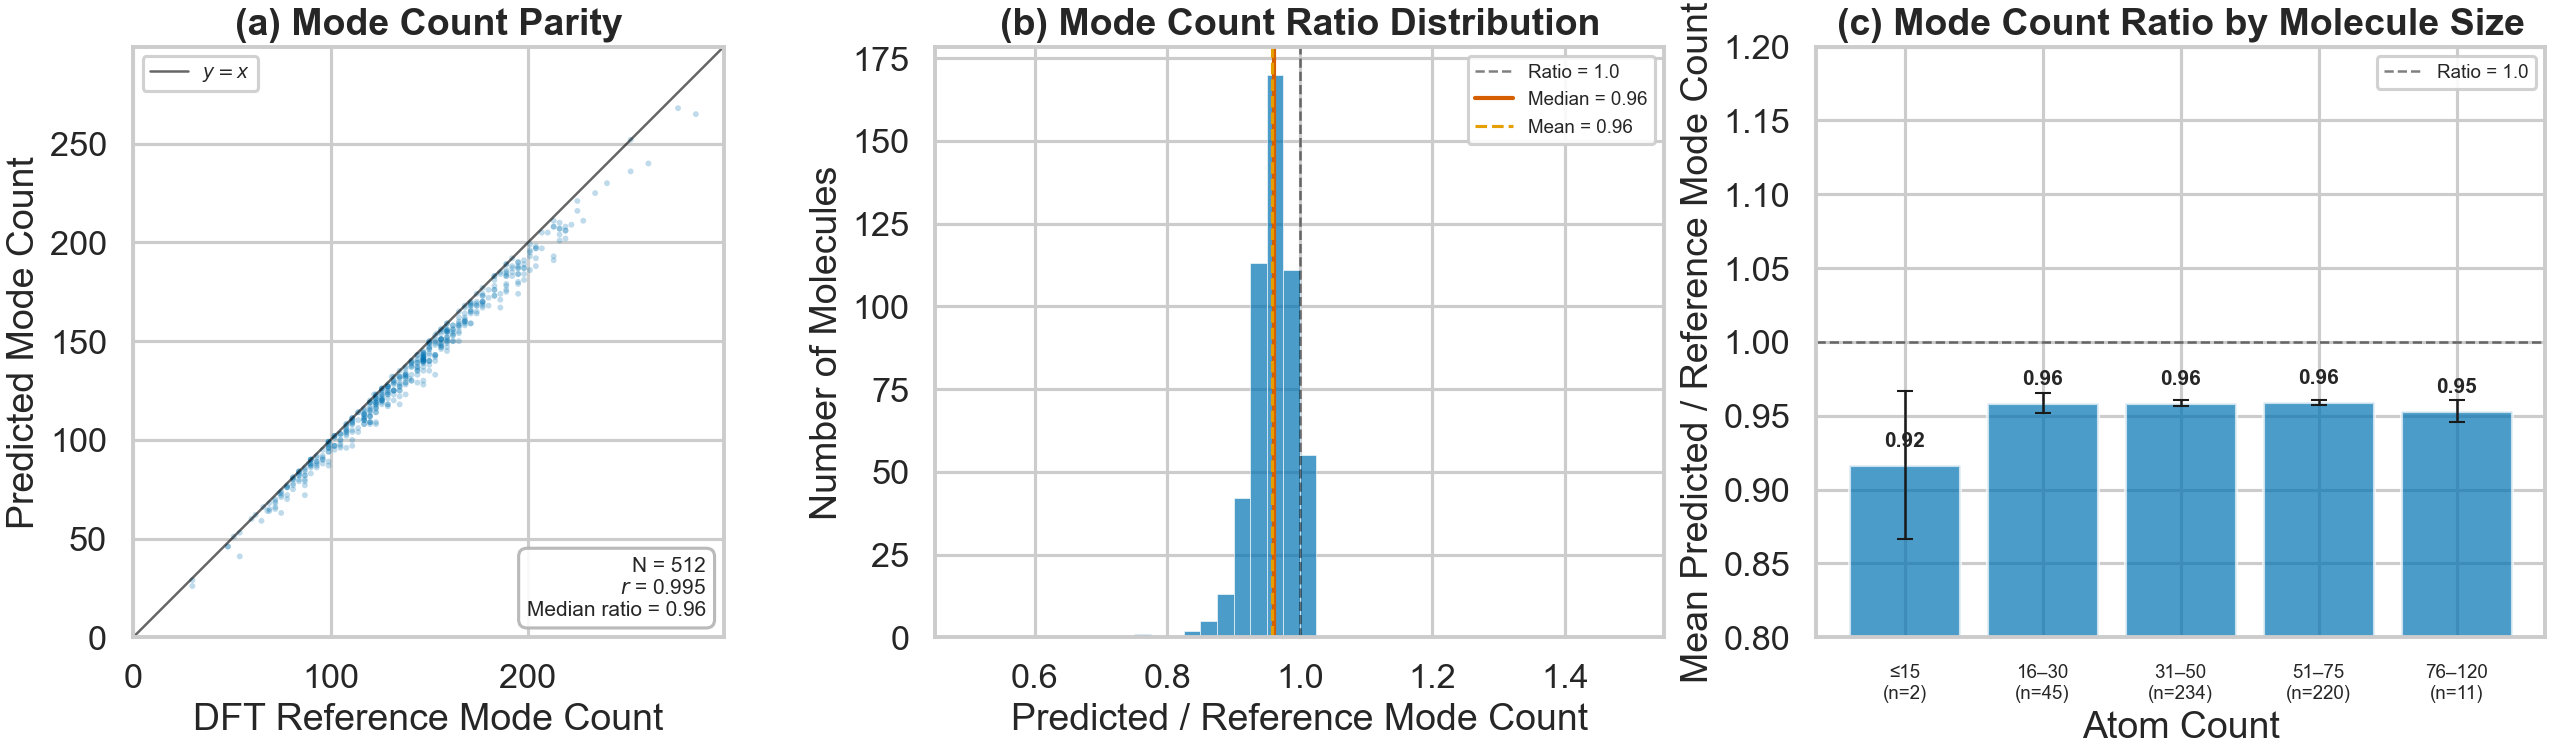

Mode count analysis (DFT benchmark, N=512):
  Median ratio (pred/ref): 0.962
  Mean ratio (pred/ref):   0.959
  Std of ratio:            0.031
  IQR of ratio:            [0.942, 0.981]
Saved fig_mode_counts


In [8]:
# === MODE COUNT ANALYSIS ===
# Verify the paper's claim: "predicted-to-reference mode-count ratio is 1.02"

per_mol_csv = OUT_DIR / 'stats_per_molecule.csv'
if not per_mol_csv.exists():
    per_mol_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_per_molecule.csv'
mc_df = pd.read_csv(per_mol_csv) if per_mol_csv.exists() else pd.DataFrame()

# DFT benchmark molecules: n_pred_modes (model output) vs n_dft_lines (DFT reference)
dft_mc = mc_df[mc_df['benchmark_group'] == 'dft'].copy() if 'benchmark_group' in mc_df.columns else pd.DataFrame()

if len(dft_mc) > 0 and 'n_pred_modes' in dft_mc.columns and 'n_dft_lines' in dft_mc.columns:
    pred_counts = dft_mc['n_pred_modes'].dropna().values
    ref_counts = dft_mc['n_dft_lines'].dropna().values
    n_valid = min(len(pred_counts), len(ref_counts))
    pred_counts = pred_counts[:n_valid]
    ref_counts = ref_counts[:n_valid]
    
    # Compute ratio (pred / ref), excluding cases where ref == 0
    valid_mask = ref_counts > 0
    ratios = pred_counts[valid_mask] / ref_counts[valid_mask]
    
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    
    # --- (a) Scatter: predicted vs reference mode counts ---
    ax = axes[0]
    ax.scatter(ref_counts, pred_counts, s=8, alpha=0.25, color=C_PRED, edgecolors='none', rasterized=True)
    max_val = max(ref_counts.max(), pred_counts.max()) * 1.05
    ax.plot([0, max_val], [0, max_val], color=C_REF, lw=1.2, ls='-', alpha=0.6, label='$y = x$')
    ax.set_xlabel('DFT Reference Mode Count')
    ax.set_ylabel('Predicted Mode Count')
    ax.set_title('(a) Mode Count Parity')
    ax.set_xlim(0, max_val); ax.set_ylim(0, max_val)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=9)
    # Annotate stats
    from scipy.stats import pearsonr
    r_val, _ = pearsonr(ref_counts[valid_mask], pred_counts[valid_mask])
    ax.text(0.97, 0.03,
            f'N = {valid_mask.sum()}\n$r$ = {r_val:.3f}\nMedian ratio = {np.median(ratios):.2f}',
            transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='0.7', alpha=0.9))
    
    # --- (b) Histogram of pred/ref ratio ---
    ax = axes[1]
    ax.hist(ratios, bins=40, range=(0.5, 1.5), color=C_PRED, alpha=0.7, edgecolor='white', linewidth=0.4)
    med_ratio = np.median(ratios)
    mean_ratio = np.mean(ratios)
    ax.axvline(1.0, color=C_REF, lw=1.2, ls='--', alpha=0.5, label='Ratio = 1.0')
    ax.axvline(med_ratio, color=WONG['vermillion'], lw=2, ls='-',
               label=f'Median = {med_ratio:.2f}')
    ax.axvline(mean_ratio, color=WONG['orange'], lw=1.5, ls='--',
               label=f'Mean = {mean_ratio:.2f}')
    ax.set_xlabel('Predicted / Reference Mode Count')
    ax.set_ylabel('Number of Molecules')
    ax.set_title('(b) Mode Count Ratio Distribution')
    ax.legend(fontsize=9)
    
    # --- (c) Summary bar chart: mean ratio by molecule size bin ---
    ax = axes[2]
    tmp = dft_mc[valid_mask.tolist()[:len(dft_mc)]].copy() if 'n_atoms' in dft_mc.columns else pd.DataFrame()
    if 'n_atoms' in tmp.columns and len(tmp) > 0:
        tmp['ratio'] = tmp['n_pred_modes'] / tmp['n_dft_lines']
        tmp['size_bin'] = pd.cut(tmp['n_atoms'], bins=[0, 15, 30, 50, 75, 120],
                                  labels=['\u226415', '16\u201330', '31\u201350', '51\u201375', '76\u2013120'])
        bin_stats = tmp.groupby('size_bin', observed=True)['ratio'].agg(['mean', 'median', 'std', 'count'])
        
        x = range(len(bin_stats))
        bars = ax.bar(x, bin_stats['mean'],
                      yerr=bin_stats['std'] / np.sqrt(bin_stats['count']),
                      color=C_PRED, alpha=0.7, edgecolor='white', capsize=4, error_kw={'lw': 1.2})
        ax.set_xticks(x)
        ax.set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in bin_stats.iterrows()], fontsize=9)
        ax.axhline(1.0, color=C_REF, lw=1.2, ls='--', alpha=0.5, label='Ratio = 1.0')
        ax.set_xlabel('Atom Count')
        ax.set_ylabel('Mean Predicted / Reference Mode Count')
        ax.set_title('(c) Mode Count Ratio by Molecule Size')
        ax.set_ylim(0.8, 1.2)
        ax.legend(fontsize=9)
        for bar, val in zip(bars, bin_stats['mean']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'n_atoms column not available', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='0.5')
    
    fig.savefig(OUT_DIR / 'fig_mode_counts.png', dpi=300)
    fig.savefig(OUT_DIR / 'fig_mode_counts.pdf')
    plt.show()
    
    print(f'Mode count analysis (DFT benchmark, N={valid_mask.sum()}):')
    print(f'  Median ratio (pred/ref): {med_ratio:.3f}')
    print(f'  Mean ratio (pred/ref):   {mean_ratio:.3f}')
    print(f'  Std of ratio:            {np.std(ratios):.3f}')
    print(f'  IQR of ratio:            [{np.percentile(ratios, 25):.3f}, {np.percentile(ratios, 75):.3f}]')
    print(f'Saved fig_mode_counts')
else:
    cols = list(mc_df.columns[:15]) if len(mc_df) > 0 else []
    print(f'Mode count columns not found. Available: {cols}')

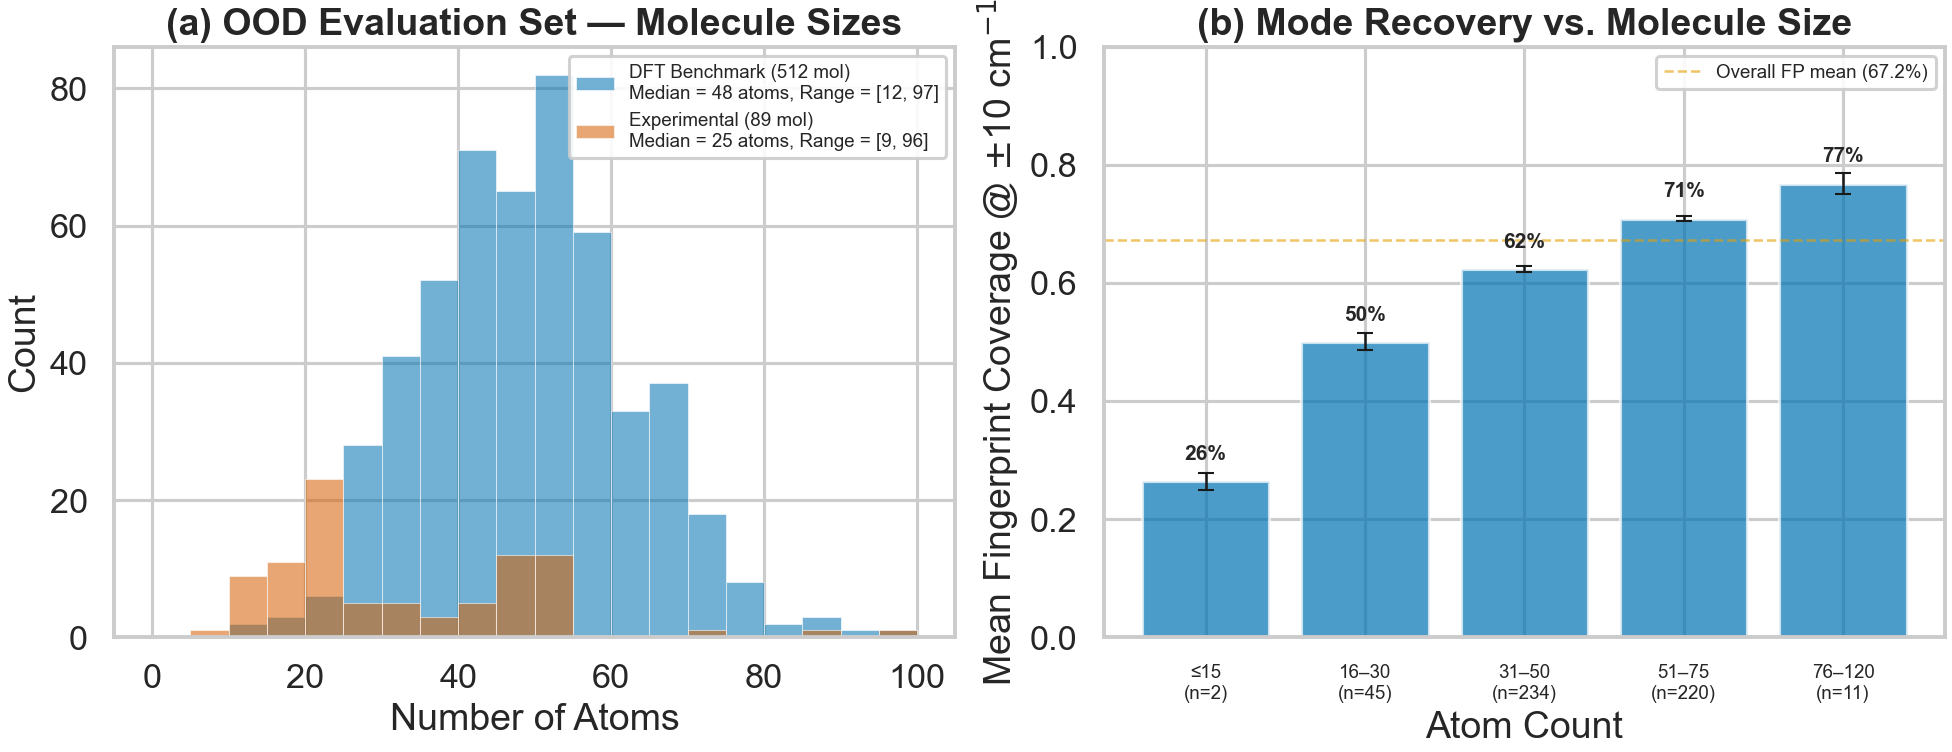

Saved fig3_molecule_sizes


In [9]:
# === FIGURE 3: Molecule Size Distribution + Coverage by Size ===
per_mol_csv = OUT_DIR / 'stats_per_molecule.csv'
if not per_mol_csv.exists():
    per_mol_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_per_molecule.csv'
pm_df = pd.read_csv(per_mol_csv) if per_mol_csv.exists() else pd.DataFrame()

if 'n_atoms' in pm_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Panel A: Atom count distribution
    for bg, color, label in [('dft', C_PRED, 'DFT Benchmark (512 mol)'), 
                               ('experimental', C_EXP, 'Experimental (89 mol)')]:
        subset = pm_df[pm_df['benchmark_group'] == bg]['n_atoms'].dropna()
        if len(subset) > 0:
            axes[0].hist(subset, bins=range(0, int(subset.max())+5, 5), alpha=0.55, 
                        color=color, edgecolor='white', linewidth=0.5,
                        label=f'{label}\nMedian = {int(subset.median())} atoms, Range = [{int(subset.min())}, {int(subset.max())}]')
    axes[0].set_xlabel('Number of Atoms')
    axes[0].set_ylabel('Count')
    axes[0].set_title('(a) OOD Evaluation Set \u2014 Molecule Sizes')
    axes[0].legend(fontsize=9)
    
    # Panel B: Coverage vs molecule size
    dft_mols = pm_df[pm_df['benchmark_group'] == 'dft'].copy()
    cov_col = [c for c in dft_mols.columns if 'coverage_any__dft_raw_line__DFT->Pred__fingerprint__tol_10' in c]
    if cov_col:
        dft_mols['fp_cov'] = dft_mols[cov_col[0]]
        dft_mols['size_bin'] = pd.cut(dft_mols['n_atoms'], bins=[0, 15, 30, 50, 75, 120], 
                                       labels=['\u226415', '16\u201330', '31\u201350', '51\u201375', '76\u2013120'])
        bin_stats = dft_mols.groupby('size_bin', observed=True)['fp_cov'].agg(['mean', 'count', 'std', 'median'])
        
        x = range(len(bin_stats))
        bars = axes[1].bar(x, bin_stats['mean'], yerr=bin_stats['std']/np.sqrt(bin_stats['count']),
                           color=C_PRED, alpha=0.7, edgecolor='white', capsize=4, error_kw={'lw': 1.2})
        axes[1].set_xticks(x)
        axes[1].set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in bin_stats.iterrows()], fontsize=9)
        axes[1].set_xlabel('Atom Count')
        axes[1].set_ylabel(r'Mean Fingerprint Coverage @ $\pm$10 cm$^{-1}$')
        axes[1].set_title('(b) Mode Recovery vs. Molecule Size')
        axes[1].set_ylim(0, 1.0)
        axes[1].axhline(0.672, color=WONG['orange'], lw=1.2, ls='--', alpha=0.6, label='Overall FP mean (67.2%)')
        axes[1].legend(fontsize=9)
        
        for bar, val in zip(bars, bin_stats['mean']):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                        f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, 'Coverage column not found', ha='center', va='center',
                    transform=axes[1].transAxes, fontsize=11, color='0.5')
        print('Available coverage cols:', [c for c in dft_mols.columns if 'coverage' in c.lower()][:5])
    
    fig.savefig(OUT_DIR / 'fig3_molecule_sizes.png', dpi=300)
    fig.savefig(OUT_DIR / 'fig3_molecule_sizes.pdf')
    plt.show()
    print('Saved fig3_molecule_sizes')
else:
    print('n_atoms column not found')

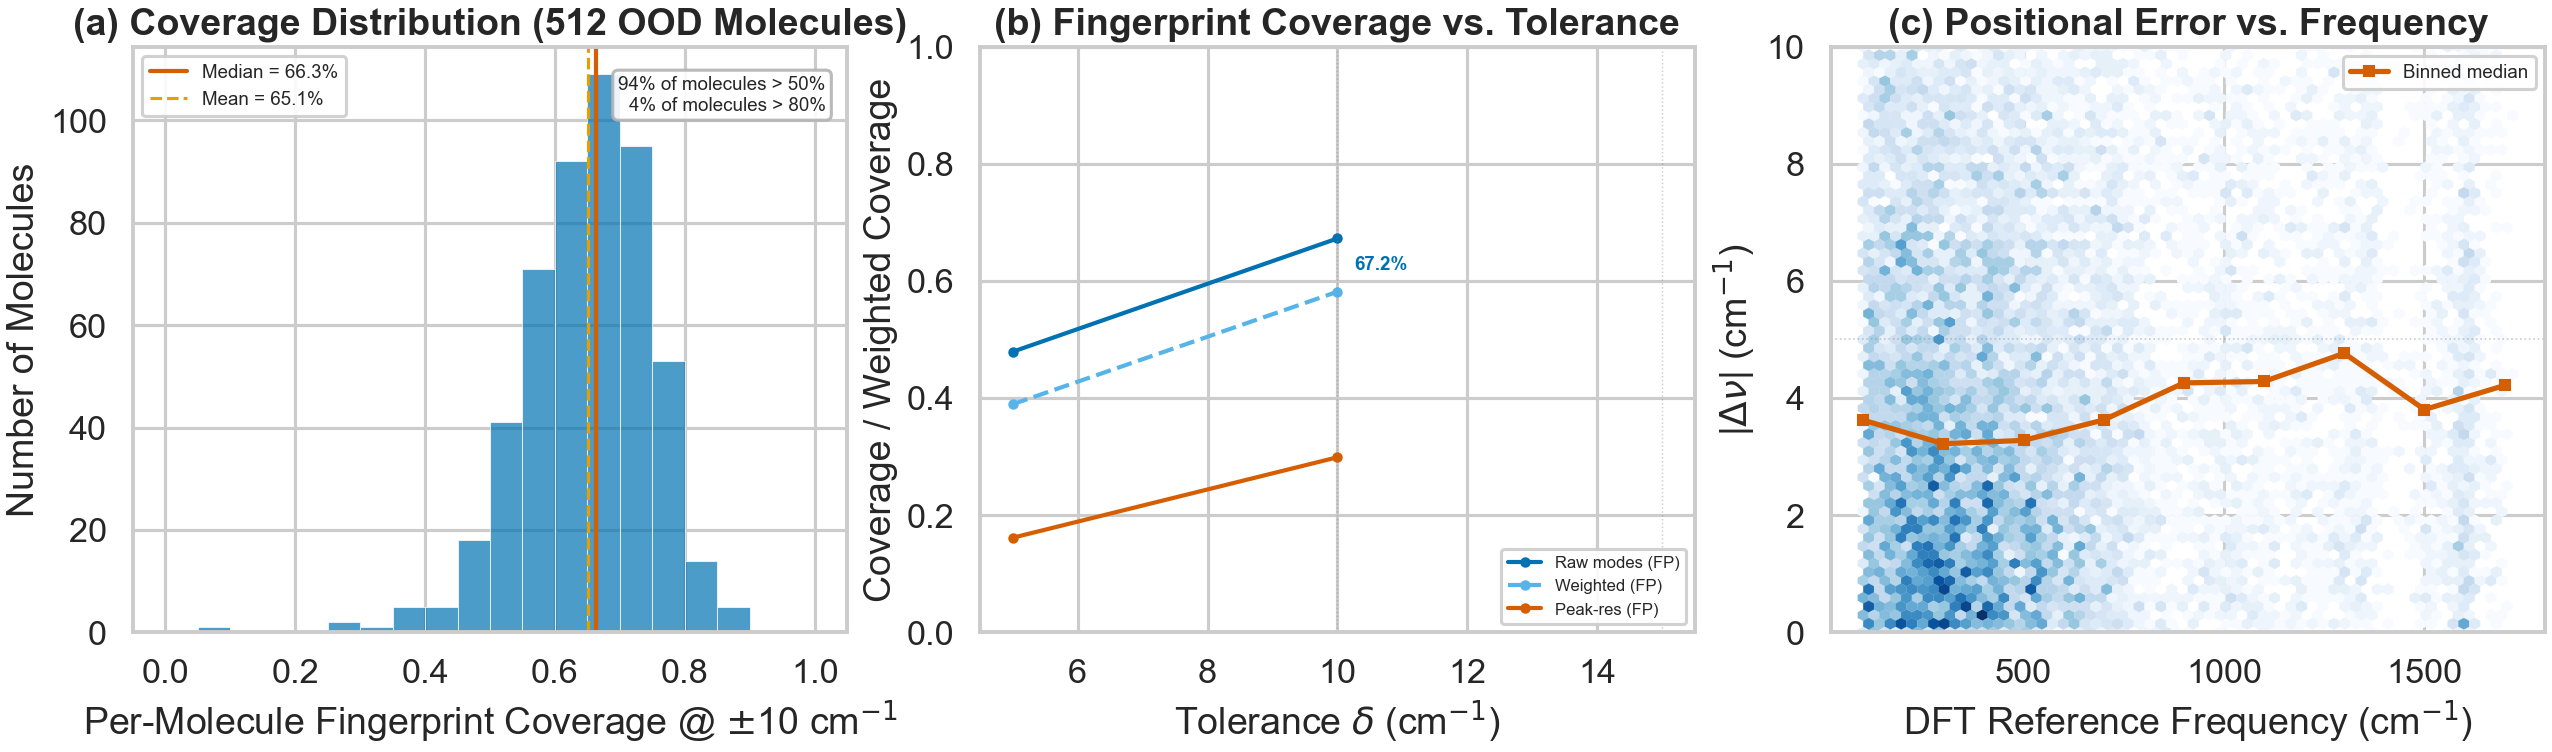

Saved fig4_narrative_plots


In [10]:
# === FIGURE 4: Three narrative-selling plots ===
# (a) Per-molecule coverage histogram  (b) Custom tolerance sweep  (c) |Δν| vs frequency

# Helper to extract a row from the executive summary (needed here and in later cells)
def get_row(df, bm_prefix, pair, region, tol):
    mask = df['benchmark'].str.startswith(bm_prefix) & (df['pair']==pair) & (df['region']==region) & (df['tol_cm']==tol)
    return df[mask].iloc[0] if mask.any() else None

ll_csv = OUT_DIR / 'stats_line_level_matches.csv'
if not ll_csv.exists():
    ll_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_line_level_matches.csv'
ll = pd.read_csv(ll_csv) if ll_csv.exists() else pd.DataFrame()

pm_path = OUT_DIR / 'stats_per_molecule.csv'
if not pm_path.exists():
    pm_path = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_per_molecule.csv'
pm_df = pd.read_csv(pm_path) if pm_path.exists() else pd.DataFrame()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- (a) Per-molecule fingerprint coverage histogram ---
ax = axes[0]
dft_pm = pm_df[pm_df['benchmark_group'] == 'dft'].copy() if 'benchmark_group' in pm_df.columns else pd.DataFrame()
cov_col = [c for c in dft_pm.columns if 'coverage_any__dft_raw_line__DFT->Pred__fingerprint__tol_10' in c]
if cov_col and len(dft_pm) > 0:
    vals = dft_pm[cov_col[0]].dropna().values
    ax.hist(vals, bins=20, range=(0, 1), color=C_PRED, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(np.median(vals), color=WONG['vermillion'], lw=2, ls='-', 
               label=f'Median = {np.median(vals):.1%}')
    ax.axvline(np.mean(vals), color=WONG['orange'], lw=1.5, ls='--',
               label=f'Mean = {np.mean(vals):.1%}')
    # Fraction above thresholds
    pct_50 = np.mean(vals >= 0.5)
    pct_80 = np.mean(vals >= 0.8)
    ax.text(0.97, 0.95, f'{pct_50:.0%} of molecules > 50%\n{pct_80:.0%} of molecules > 80%',
            transform=ax.transAxes, fontsize=9, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='0.7', alpha=0.9))
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Coverage column not found', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel(r'Per-Molecule Fingerprint Coverage @ $\pm$10 cm$^{-1}$')
ax.set_ylabel('Number of Molecules')
ax.set_title('(a) Coverage Distribution (512 OOD Molecules)')

# --- (b) Custom tolerance sweep (fingerprint only, annotated) ---
ax = axes[1]
odf = exec_df  # current run's exec_df
tol_vals = sorted(odf['tol_cm'].unique()) if 'tol_cm' in odf.columns else []

if tol_vals:
    for bm_prefix, pair, region, label, color, ls in [
        ('DFT mode-position', 'DFT->Pred', 'fingerprint', 'Raw modes (FP)', C_PRED, '-'),
        ('DFT mode-position', 'DFT->Pred', 'fingerprint', 'Weighted (FP)', C_ACC, '--'),
        ('DFT peak-resolution', 'DFT->Pred', 'fingerprint', 'Peak-res (FP)', C_EXP, '-'),
    ]:
        cov_metric = 'weighted_coverage_any_global' if 'Weighted' in label else 'coverage_any_global'
        sweep_vals = []
        for tol in tol_vals:
            r = get_row(odf, bm_prefix, pair, region, tol)
            if r is not None:
                sweep_vals.append((tol, r[cov_metric]))
        if sweep_vals:
            ts, cs = zip(*sweep_vals)
            ax.plot(ts, cs, color=color, lw=2, ls=ls, marker='o', markersize=4, label=label)
    
    # Annotate key thresholds
    for tol_mark in [10, 15]:
        ax.axvline(tol_mark, color='gray', lw=0.7, ls=':', alpha=0.4)
    
    # Annotate the ±10 and ±15 values
    r10 = get_row(odf, 'DFT mode-position', 'DFT->Pred', 'fingerprint', 10.0)
    r15 = get_row(odf, 'DFT mode-position', 'DFT->Pred', 'fingerprint', 15.0) if 15.0 in tol_vals else None
    if r10 is not None:
        ax.annotate(f"{r10['coverage_any_global']:.1%}", (10, r10['coverage_any_global']),
                   textcoords='offset points', xytext=(8, -15), fontsize=9, fontweight='bold', color=C_PRED)
    if r15 is not None:
        ax.annotate(f"{r15['coverage_any_global']:.1%}", (15, r15['coverage_any_global']),
                   textcoords='offset points', xytext=(8, -15), fontsize=9, fontweight='bold', color=C_PRED)
    
    ax.legend(fontsize=8, loc='lower right')
ax.set_xlabel(r'Tolerance $\delta$ (cm$^{-1}$)')
ax.set_ylabel('Coverage / Weighted Coverage')
ax.set_title(r'(b) Fingerprint Coverage vs. Tolerance')
ax.set_ylim(0, 1.0)

# --- (c) |Δν| vs reference frequency ---
ax = axes[2]
dnu_col = 'signed_dnu_cm' if 'signed_dnu_cm' in ll.columns else 'signed_dnu'
src_col = 'source_freq_cm' if 'source_freq_cm' in ll.columns else 'source_freq'

dft_fp = ll[(ll['benchmark'] == 'dft_raw_line') & (ll['pair'] == 'DFT->Pred') &
             (ll['region'] == 'full') & (ll['tol_cm'] == 10.0)]

if len(dft_fp) > 0 and dnu_col in dft_fp.columns and src_col in dft_fp.columns:
    freqs = dft_fp[src_col].values
    errs = np.abs(dft_fp[dnu_col].values)
    
    # Hexbin for density
    hb = ax.hexbin(freqs, errs, gridsize=60, cmap='Blues', mincnt=1, linewidths=0.1)
    
    # Binned median trend line
    freq_bins = np.arange(0, 3600, 200)
    bin_meds = []
    bin_centers = []
    for lo, hi in zip(freq_bins[:-1], freq_bins[1:]):
        mask_bin = (freqs >= lo) & (freqs < hi)
        if mask_bin.sum() >= 10:
            bin_meds.append(np.median(errs[mask_bin]))
            bin_centers.append((lo + hi) / 2)
    if bin_centers:
        ax.plot(bin_centers, bin_meds, color=WONG['vermillion'], lw=2.5, marker='s', markersize=5,
                label=f'Binned median', zorder=5)
    
    ax.axhline(5, color='gray', lw=0.8, ls=':', alpha=0.4)
    ax.set_xlabel(r'DFT Reference Frequency (cm$^{-1}$)')
    ax.set_ylabel(r'|$\Delta\nu$| (cm$^{-1}$)')
    ax.set_title(r'(c) Positional Error vs. Frequency')
    ax.set_ylim(0, 10)
    ax.legend(fontsize=9)

fig.savefig(OUT_DIR / 'fig4_narrative_plots.png', dpi=300)
fig.savefig(OUT_DIR / 'fig4_narrative_plots.pdf')
plt.show()
print('Saved fig4_narrative_plots')

In [11]:
# === TABLES: DFT + Peak-Resolution + Experimental ===
# Helper to extract a row from the executive summary
def get_row(df, bm_prefix, pair, region, tol):
    mask = df['benchmark'].str.startswith(bm_prefix) & (df['pair']==pair) & (df['region']==region) & (df['tol_cm']==tol)
    return df[mask].iloc[0] if mask.any() else None

# Use current run's exec_df (filter_visible_lines=False)
odf = exec_df

# === TABLE 1: DFT Mode Recovery ===
dft_rows = []
for region, label in [('full range', 'Full range'), ('fingerprint', 'Fingerprint (400–1800)')]:
    for tol in [5.0, 10.0]:
        r = get_row(odf, 'DFT mode-position', 'DFT->Pred', region, tol)
        if r is not None:
            dft_rows.append({
                'Region': label, 'Tolerance': f'±{int(tol)} cm⁻¹',
                'Coverage': f"{r['coverage_any_global']:.1%}",
                'Wt. Coverage': f"{r['weighted_coverage_any_global']:.1%}",
                'F1 (Hungarian)': f"{r['f1']:.3f}",
                'Median |Δν|': f"{r['median_abs_dnu_cm_pooled']:.1f}" if pd.notna(r.get('median_abs_dnu_cm_pooled')) else '—',
                'Int. MAE (log₁₀)': f"{r['mae_log10_ratio_pooled']:.3f}" if pd.notna(r.get('mae_log10_ratio_pooled')) else '—',
            })
dft_table = pd.DataFrame(dft_rows)
print('TABLE 1: DFT Vibrational Mode Recovery (512 OOD molecules)')
print('Training: SPICE, NABLA2DFT, QM9, QM7 | Evaluation: RamanChemBL (zero-shot)')
display(dft_table)
dft_table.to_csv(OUT_DIR / 'table1_dft_results.csv', index=False)

# === DFT Peak-Resolution ===
print('\nDFT Peak-Resolution Benchmark (stricter — after broadening + peak extraction):')
peak_rows = []
for region, label in [('full range', 'Full range'), ('fingerprint', 'Fingerprint')]:
    r = get_row(odf, 'DFT peak-resolution', 'DFT->Pred', region, 10.0)
    if r is not None:
        peak_rows.append({
            'Region': label,
            'Coverage@10': f"{r['coverage_any_global']:.1%}",
            'Wt. Cov@10': f"{r['weighted_coverage_any_global']:.1%}",
            'F1@10': f"{r['f1']:.3f}",
        })
display(pd.DataFrame(peak_rows))

# === TABLE 2: Experimental Transfer ===
print('\nTABLE 2: Experimental Transfer (89 molecules, fingerprint region)')
exp_rows = []
for tol in [5.0, 10.0]:
    r = get_row(odf, 'Experimental peak', 'Exp->Pred', 'fingerprint', tol)
    if r is not None:
        exp_rows.append({
            'Tolerance': f'±{int(tol)} cm⁻¹',
            'Coverage': f"{r['coverage_any_global']:.1%}",
            'Wt. Coverage': f"{r['weighted_coverage_any_global']:.1%}",
            'F1': f"{r['f1']:.3f}",
            'Median |Δν|': f"{r['median_abs_dnu_cm_pooled']:.1f}" if pd.notna(r.get('median_abs_dnu_cm_pooled')) else '—',
            'Int. MAE': f"{r['mae_log10_ratio_pooled']:.3f}" if pd.notna(r.get('mae_log10_ratio_pooled')) else '—',
        })
exp_table = pd.DataFrame(exp_rows)
display(exp_table)
exp_table.to_csv(OUT_DIR / 'table2_experimental_results.csv', index=False)

# === TABLE 3: Intensity Fidelity ===
print('\nTABLE 3: Intensity Fidelity')
int_rows = []
for bm, pair, region, label in [
    ('DFT mode-position', 'DFT->Pred', 'full range', 'DFT raw-line (full)'),
    ('DFT mode-position', 'DFT->Pred', 'fingerprint', 'DFT raw-line (FP)'),
    ('DFT peak-resolution', 'DFT->Pred', 'fingerprint', 'DFT peaks (FP)'),
    ('Experimental peak', 'Exp->Pred', 'fingerprint', 'Experimental (FP)'),
]:
    r = get_row(odf, bm, pair, region, 10.0)
    if r is not None and pd.notna(r.get('mae_log10_ratio_pooled')):
        mae = r['mae_log10_ratio_pooled']
        int_rows.append({
            'Benchmark': label,
            'Int. MAE (log₁₀)': f'{mae:.3f}',
            'Multiplicative Error': f'~{10**mae:.1f}×',
        })
int_table = pd.DataFrame(int_rows)
display(int_table)
int_table.to_csv(OUT_DIR / 'table3_intensity_fidelity.csv', index=False)

TABLE 1: DFT Vibrational Mode Recovery (512 OOD molecules)
Training: SPICE, NABLA2DFT, QM9, QM7 | Evaluation: RamanChemBL (zero-shot)


,Region,Tolerance,Coverage,Wt. Coverage,F1 (Hungarian),Median |Δν|,Int. MAE (log₁₀)
0,Full range,±5 cm⁻¹,43.7%,22.2%,0.131,2.1,0.852
1,Full range,±10 cm⁻¹,60.6%,33.2%,0.202,3.5,0.850
2,Fingerprint (400–1800),±5 cm⁻¹,47.9%,38.9%,0.241,2.0,0.863
3,Fingerprint (400–1800),±10 cm⁻¹,67.2%,58.1%,0.345,3.1,0.868



DFT Peak-Resolution Benchmark (stricter — after broadening + peak extraction):


,Region,Coverage@10,Wt. Cov@10,F1@10
0,Full range,23.6%,20.3%,0.107
1,Fingerprint,29.9%,25.7%,0.171



TABLE 2: Experimental Transfer (89 molecules, fingerprint region)


,Tolerance,Coverage,Wt. Coverage,F1,Median |Δν|,Int. MAE
0,±5 cm⁻¹,14.0%,10.4%,0.072,3.0,0.451
1,±10 cm⁻¹,26.9%,21.5%,0.138,5.0,0.464



TABLE 3: Intensity Fidelity


,Benchmark,Int. MAE (log₁₀),Multiplicative Error
0,DFT raw-line (full),0.850,~7.1×
1,DFT raw-line (FP),0.868,~7.4×
2,DFT peaks (FP),0.466,~2.9×
3,Experimental (FP),0.464,~2.9×


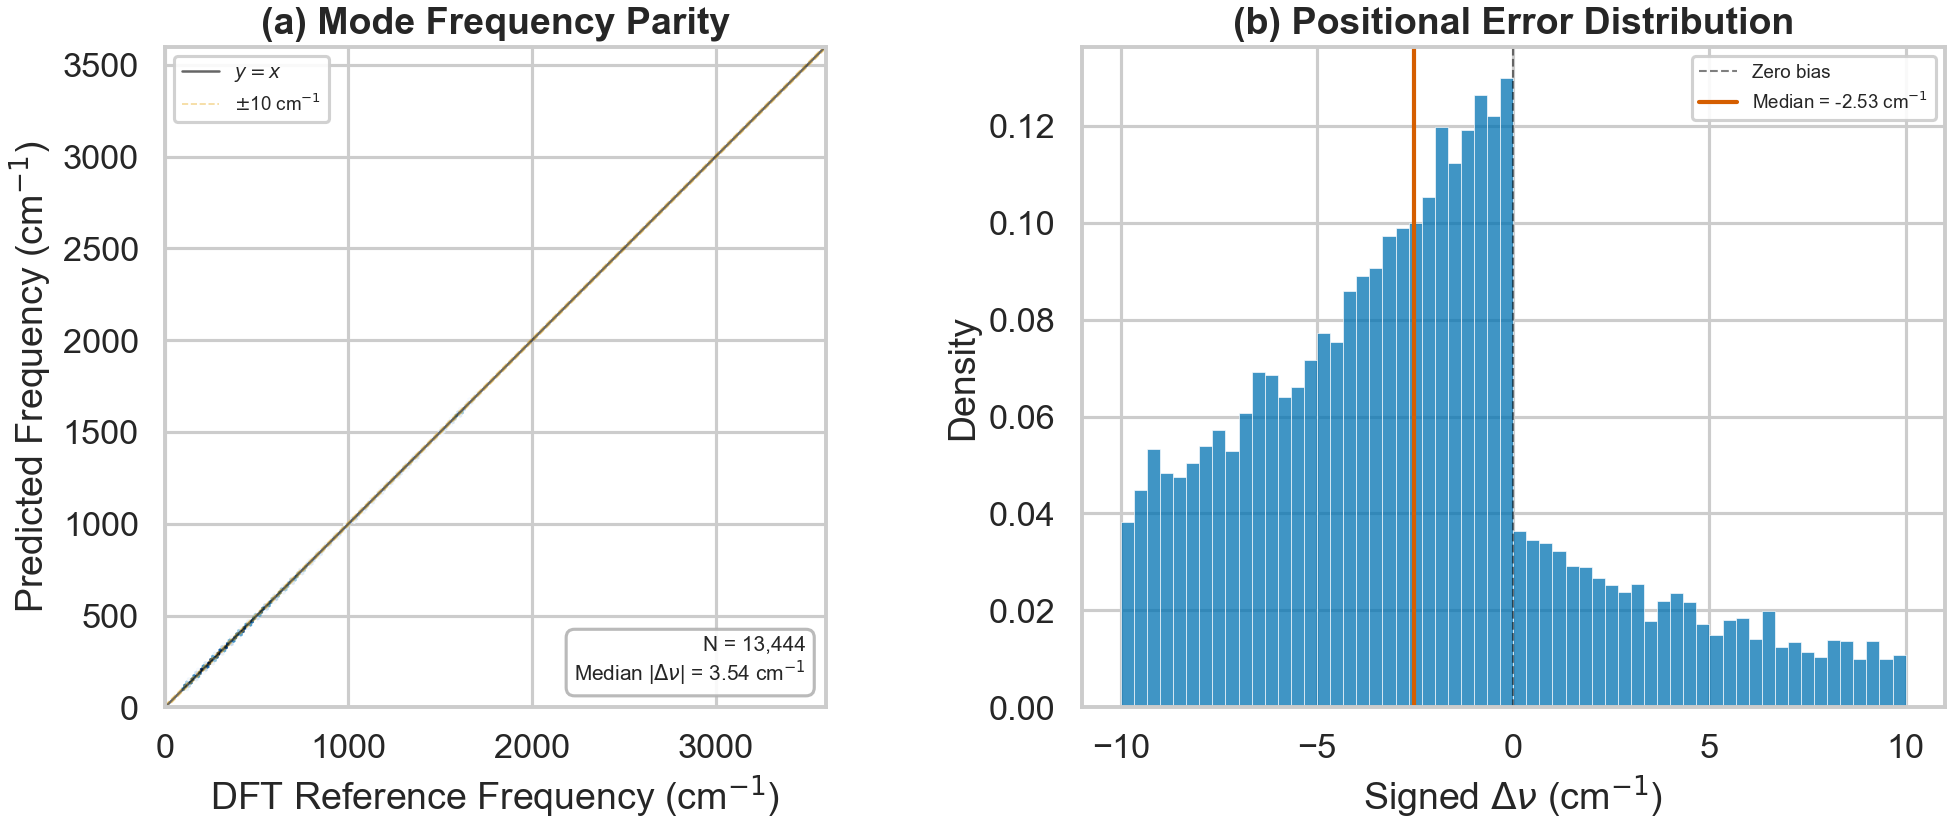

Saved fig1_frequency_parity (N=13,444 matched modes)


In [12]:
# === FIGURE 1: Frequency Parity + Signed Error ===
line_csv = OUT_DIR / 'stats_line_level_matches.csv'
if not line_csv.exists():
    line_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_line_level_matches.csv'

if line_csv.exists():
    ll = pd.read_csv(line_csv)
    src_col = 'source_freq_cm' if 'source_freq_cm' in ll.columns else 'source_freq'
    tgt_col = 'target_freq_cm' if 'target_freq_cm' in ll.columns else 'target_freq'
    dnu_col = 'signed_dnu_cm' if 'signed_dnu_cm' in ll.columns else 'signed_dnu'
    
    dft_raw = ll[(ll['benchmark'] == 'dft_raw_line') & (ll['pair'] == 'DFT->Pred') &
                  (ll['region'] == 'full') & (ll['tol_cm'] == 10.0)]
    
    if len(dft_raw) > 0 and src_col in dft_raw.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
        
        # --- Panel A: Parity scatter with density ---
        ax = axes[0]
        ax.hexbin(dft_raw[src_col], dft_raw[tgt_col], gridsize=80, cmap='Blues', mincnt=1, linewidths=0.1)
        lim = [0, 3600]
        ax.plot(lim, lim, color=C_REF, lw=1.2, ls='-', alpha=0.6, label='$y = x$')
        ax.plot(lim, [l+10 for l in lim], color=WONG['orange'], lw=0.8, ls='--', alpha=0.4)
        ax.plot(lim, [l-10 for l in lim], color=WONG['orange'], lw=0.8, ls='--', alpha=0.4, label=r'$\pm$10 cm$^{-1}$')
        ax.set_xlabel(r'DFT Reference Frequency (cm$^{-1}$)')
        ax.set_ylabel(r'Predicted Frequency (cm$^{-1}$)')
        ax.set_title('(a) Mode Frequency Parity')
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_aspect('equal')
        ax.legend(loc='upper left', fontsize=9)
        n_matched = len(dft_raw)
        med_err = np.median(np.abs(dft_raw[dnu_col].dropna()))
        ax.text(0.97, 0.03, f'N = {n_matched:,}\nMedian |$\\Delta\\nu$| = {med_err:.2f} cm$^{{-1}}$',
                transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='0.7', alpha=0.9))
        
        # --- Panel B: Signed error histogram ---
        ax = axes[1]
        vals = dft_raw[dnu_col].dropna().values
        ax.hist(vals, bins=60, range=(-10, 10), color=C_PRED, alpha=0.75, density=True,
                edgecolor='white', linewidth=0.4)
        ax.axvline(0, color=C_REF, lw=1, ls='--', alpha=0.5, label='Zero bias')
        med_val = np.median(vals)
        ax.axvline(med_val, color=WONG['vermillion'], lw=2, ls='-', 
                   label=f'Median = {med_val:+.2f} cm$^{{-1}}$')
        ax.set_xlabel(r'Signed $\Delta\nu$ (cm$^{-1}$)')
        ax.set_ylabel('Density')
        ax.set_title('(b) Positional Error Distribution')
        ax.legend(loc='upper right', fontsize=9)
        
        fig.savefig(OUT_DIR / 'fig1_frequency_parity.png', dpi=300)
        fig.savefig(OUT_DIR / 'fig1_frequency_parity.pdf')
        plt.show()
        print(f'Saved fig1_frequency_parity (N={n_matched:,} matched modes)')
    else:
        print(f'Column {src_col} not found. Available: {list(dft_raw.columns[:8])}')
else:
    print('Line-level CSV not found')

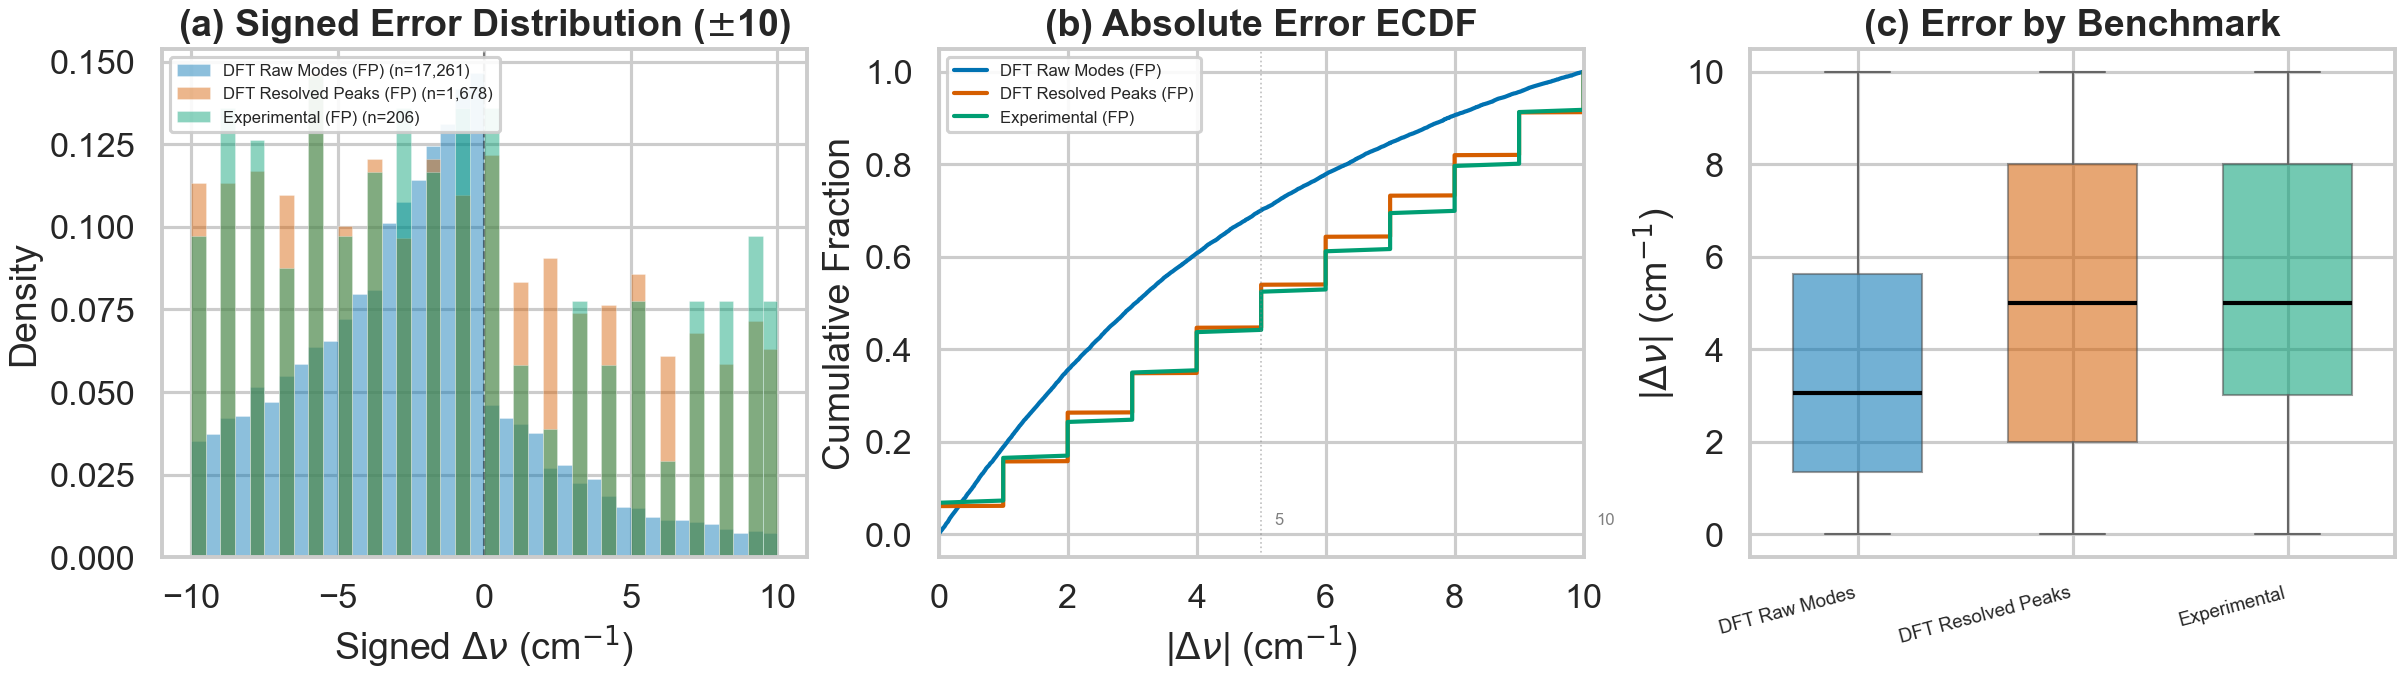

Saved fig2_error_distributions


In [13]:
# === FIGURE 2: Error Distributions — Fingerprint Benchmark Comparison ===
line_csv = OUT_DIR / 'stats_line_level_matches.csv'
if not line_csv.exists():
    line_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_line_level_matches.csv'

if line_csv.exists():
    ll = pd.read_csv(line_csv)
    dnu_col = 'signed_dnu_cm' if 'signed_dnu_cm' in ll.columns else 'signed_dnu'
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    benchmarks = [
        ('dft_raw_line', 'DFT->Pred', 'fingerprint', 'DFT Raw Modes (FP)', PALETTE[0]),
        ('dft_peak', 'DFT->Pred', 'fingerprint', 'DFT Resolved Peaks (FP)', PALETTE[1]),
        ('experimental_peak', 'Exp->Pred', 'fingerprint', 'Experimental (FP)', PALETTE[2]),
    ]
    
    for bm, pair, region, label, color in benchmarks:
        subset = ll[(ll['benchmark'] == bm) & (ll['pair'] == pair) &
                     (ll['region'] == region) & (ll['tol_cm'] == 10.0)]
        if dnu_col not in subset.columns or len(subset) == 0:
            continue
        vals = subset[dnu_col].dropna().values
        abs_vals = np.sort(np.abs(vals))
        
        # Panel A: Signed histogram
        axes[0].hist(vals, bins=40, range=(-10, 10), alpha=0.45, color=color,
                    label=f'{label} (n={len(vals):,})', density=True, edgecolor='white', linewidth=0.3)
        
        # Panel B: |Δν| ECDF
        ecdf = np.arange(1, len(abs_vals)+1) / len(abs_vals)
        axes[1].plot(abs_vals, ecdf, color=color, label=label, lw=2)
    
    # Panel A styling
    axes[0].axvline(0, color=C_REF, lw=1, ls='--', alpha=0.4)
    axes[0].set_xlabel(r'Signed $\Delta\nu$ (cm$^{-1}$)')
    axes[0].set_ylabel('Density')
    axes[0].set_title(r'(a) Signed Error Distribution ($\pm$10)')
    axes[0].legend(fontsize=8, loc='upper left')
    
    # Panel B styling
    for thr, ls in [(5, ':'), (10, '--')]:
        axes[1].axvline(thr, color='gray', lw=0.8, ls=ls, alpha=0.5)
        axes[1].text(thr + 0.2, 0.02, f'{thr}', fontsize=8, color='gray')
    axes[1].set_xlabel(r'|$\Delta\nu$| (cm$^{-1}$)')
    axes[1].set_ylabel('Cumulative Fraction')
    axes[1].set_title(r'(b) Absolute Error ECDF')
    axes[1].set_xlim(0, 10)
    axes[1].legend(fontsize=8)
    
    # Panel C: Boxplots
    box_data, box_labels, box_colors = [], [], []
    for bm, pair, region, label, color in benchmarks:
        subset = ll[(ll['benchmark'] == bm) & (ll['pair'] == pair) &
                     (ll['region'] == region) & (ll['tol_cm'] == 10.0)]
        if dnu_col in subset.columns and len(subset) > 0:
            box_data.append(np.abs(subset[dnu_col].dropna().values))
            box_labels.append(label.replace(' (FP)', ''))
            box_colors.append(color)
    
    if box_data:
        bp = axes[2].boxplot(box_data, patch_artist=True, widths=0.6,
                            medianprops=dict(color=C_REF, lw=2),
                            whiskerprops=dict(color='0.4'), capprops=dict(color='0.4'),
                            flierprops=dict(marker='.', markersize=2, alpha=0.3))
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.55)
            patch.set_edgecolor('0.3')
        axes[2].set_xticklabels(box_labels, fontsize=9, rotation=15, ha='right')
        axes[2].set_ylabel(r'|$\Delta\nu$| (cm$^{-1}$)')
        axes[2].set_title('(c) Error by Benchmark')
    
    fig.savefig(OUT_DIR / 'fig2_error_distributions.png', dpi=300)
    fig.savefig(OUT_DIR / 'fig2_error_distributions.pdf')
    plt.show()
    print('Saved fig2_error_distributions')
else:
    print('Line-level CSV not found')

FIGURE 4: Coverage Tolerance Sweep


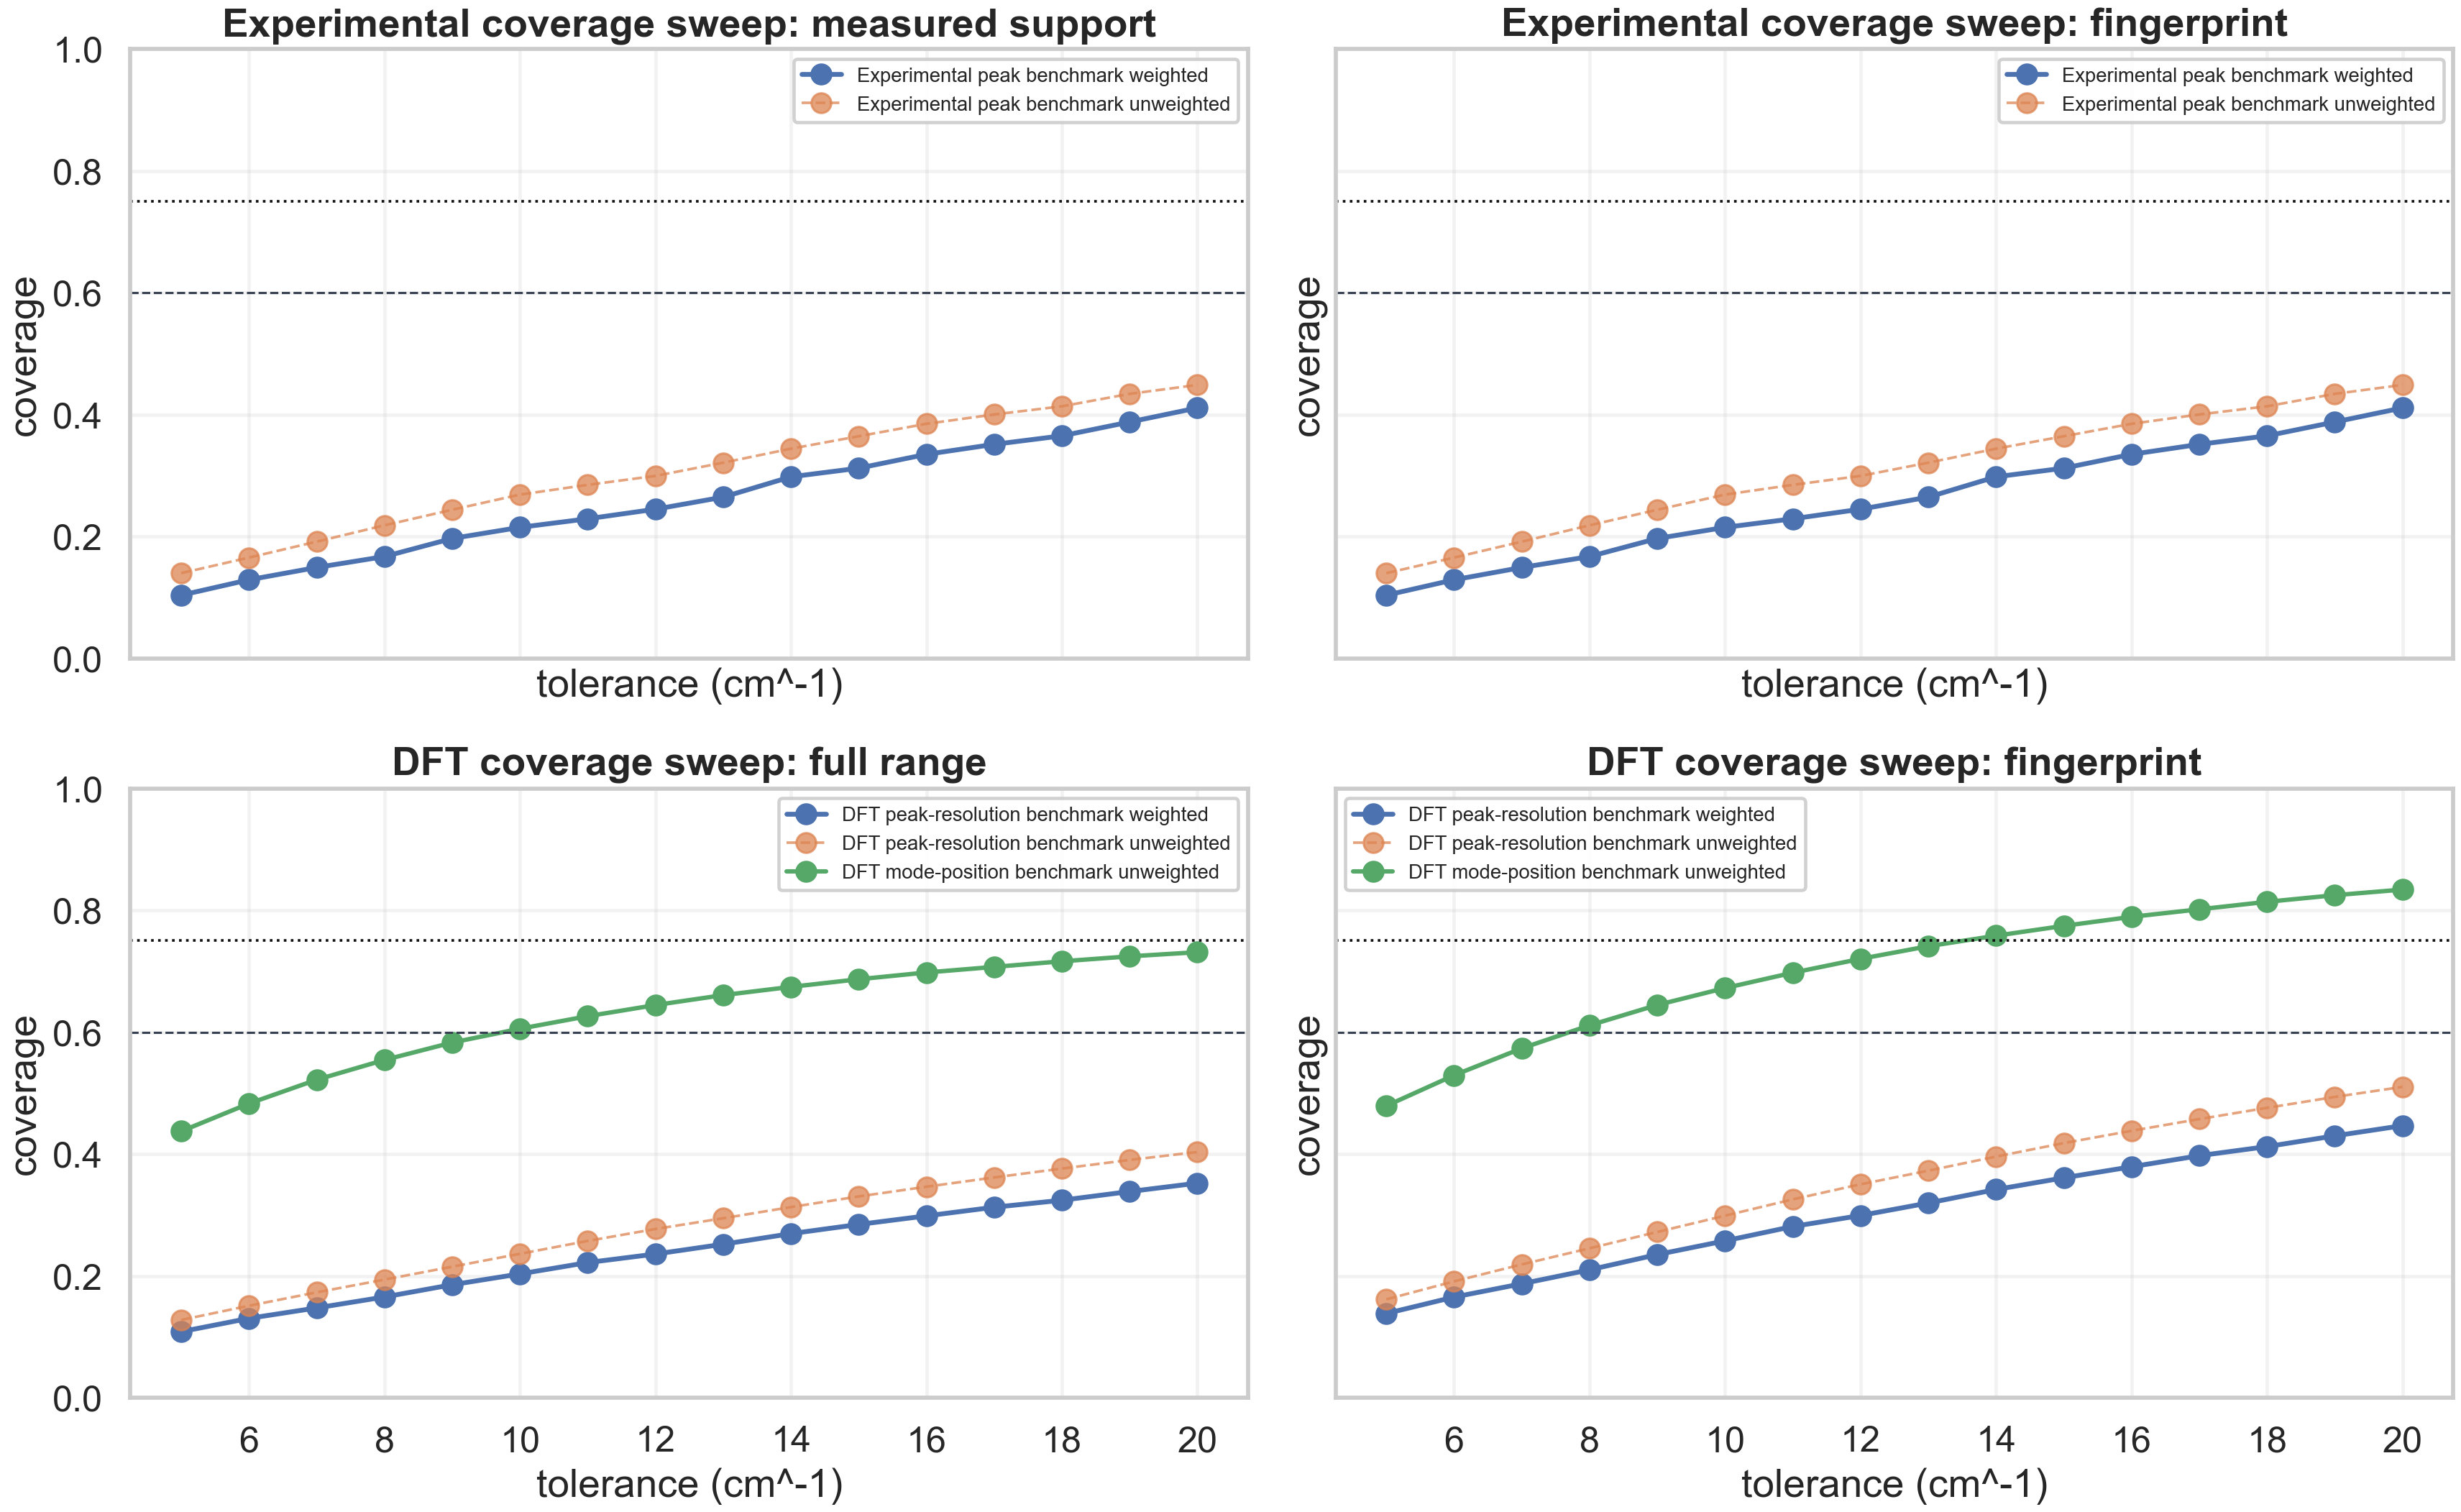

/var/folders/8l/vgsnzp1s0g54ndf86zjdlwc00000gn/T/ipykernel_29264/4107238146.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([box_data[r] for r in bp_order], labels=bp_order,


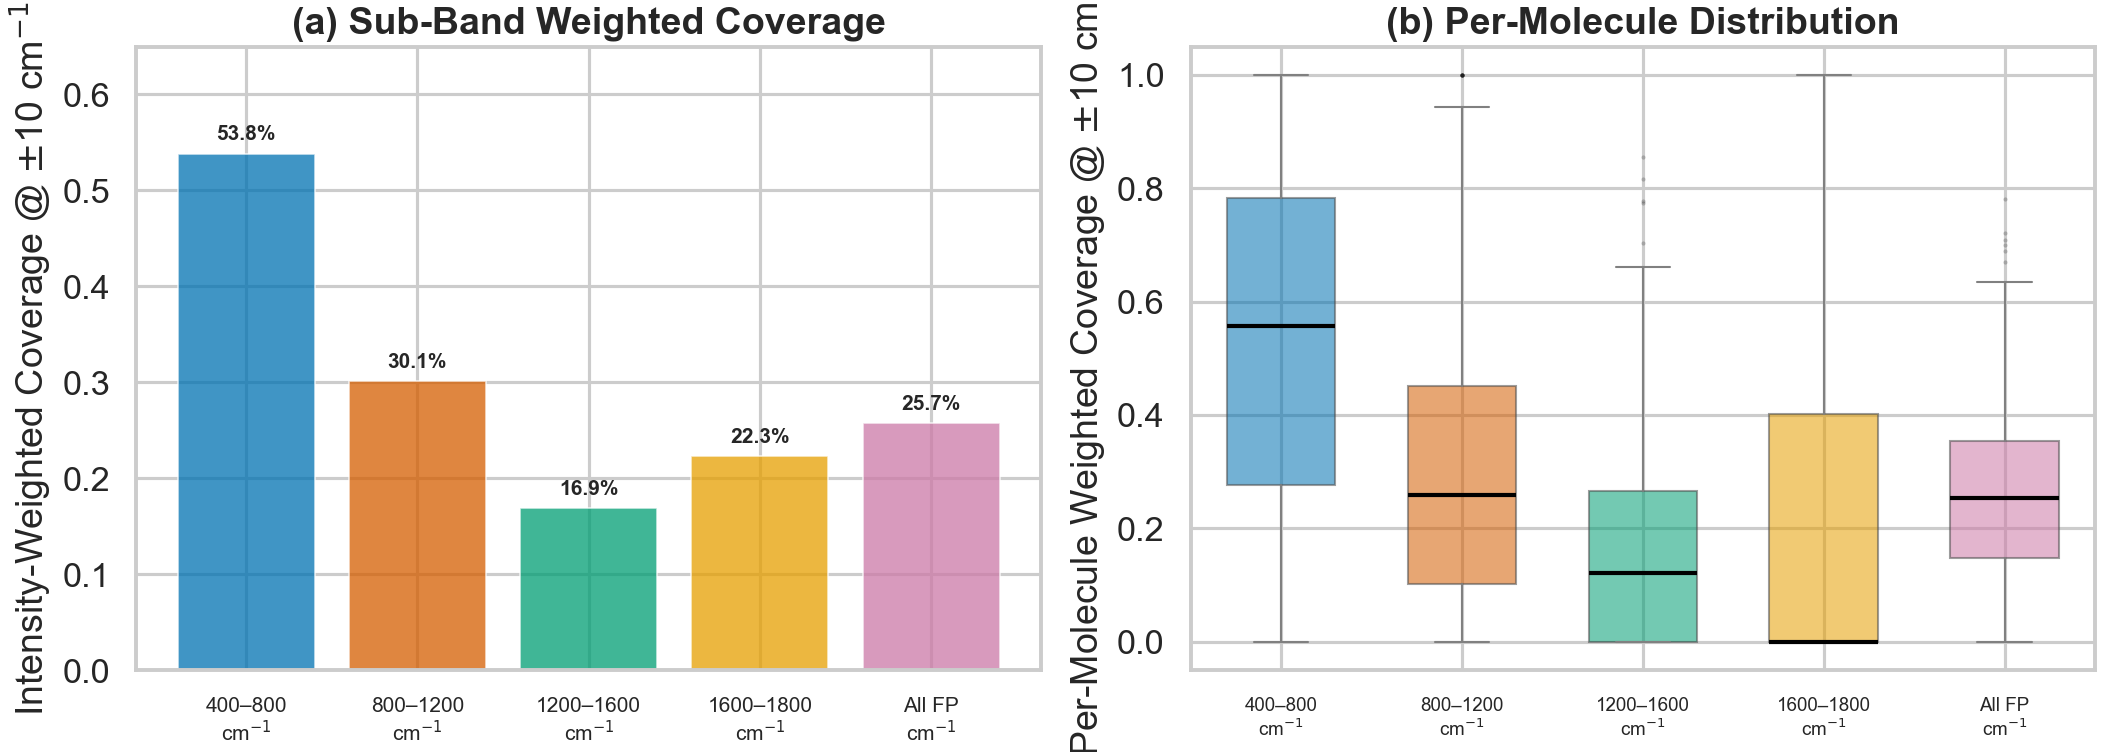

Saved fig5_subband_coverage


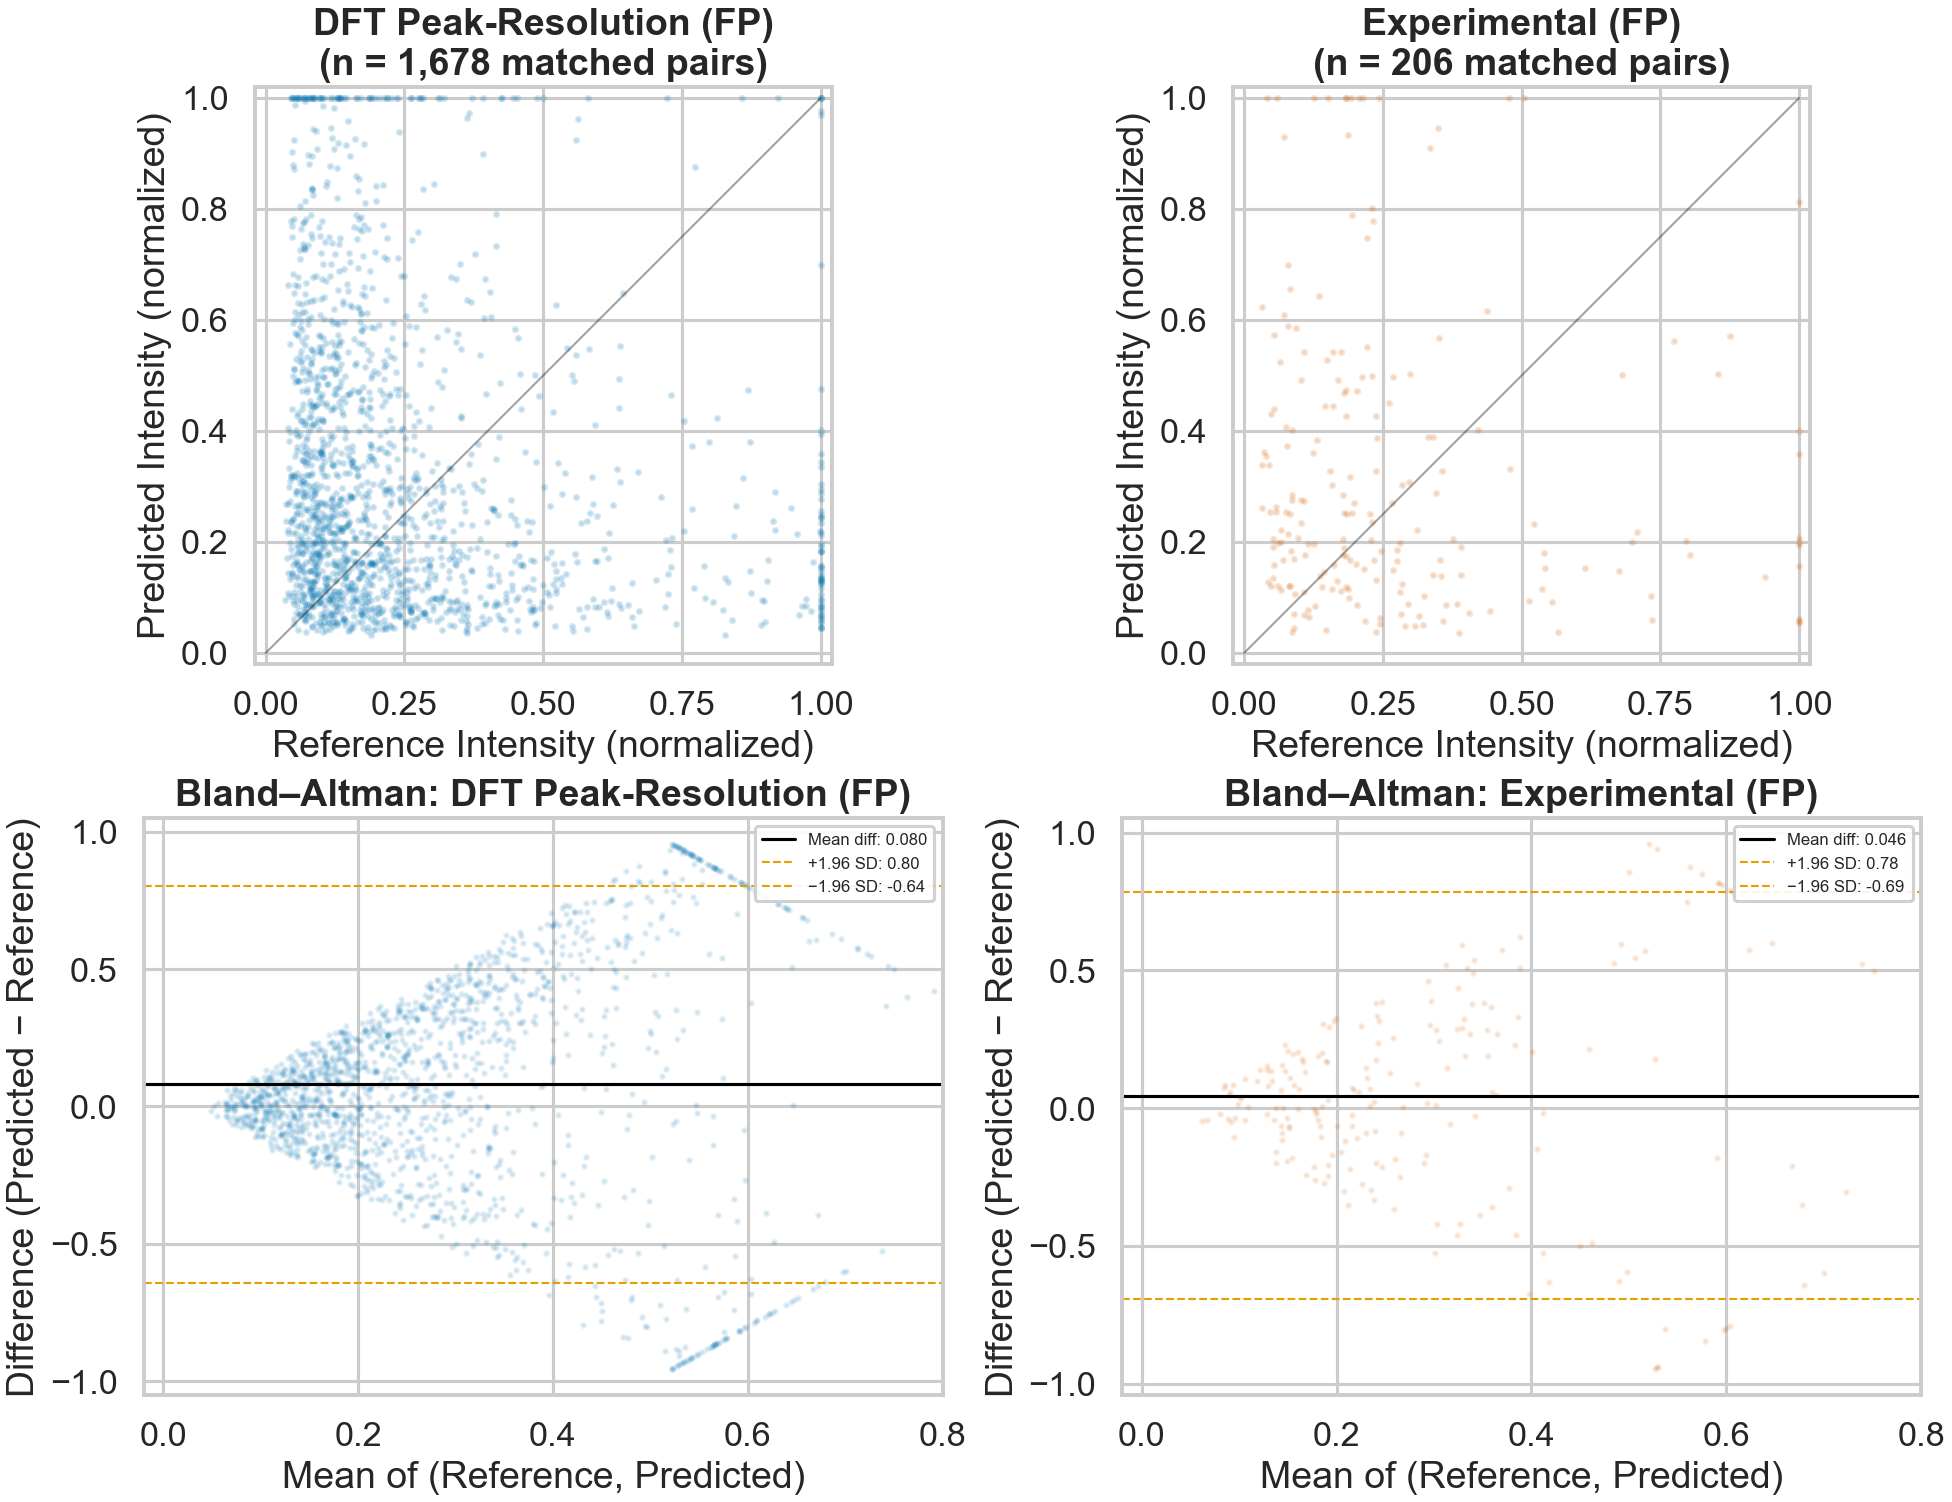

Saved fig6_intensity_agreement

FIGURE 7: Scale Factor Sensitivity


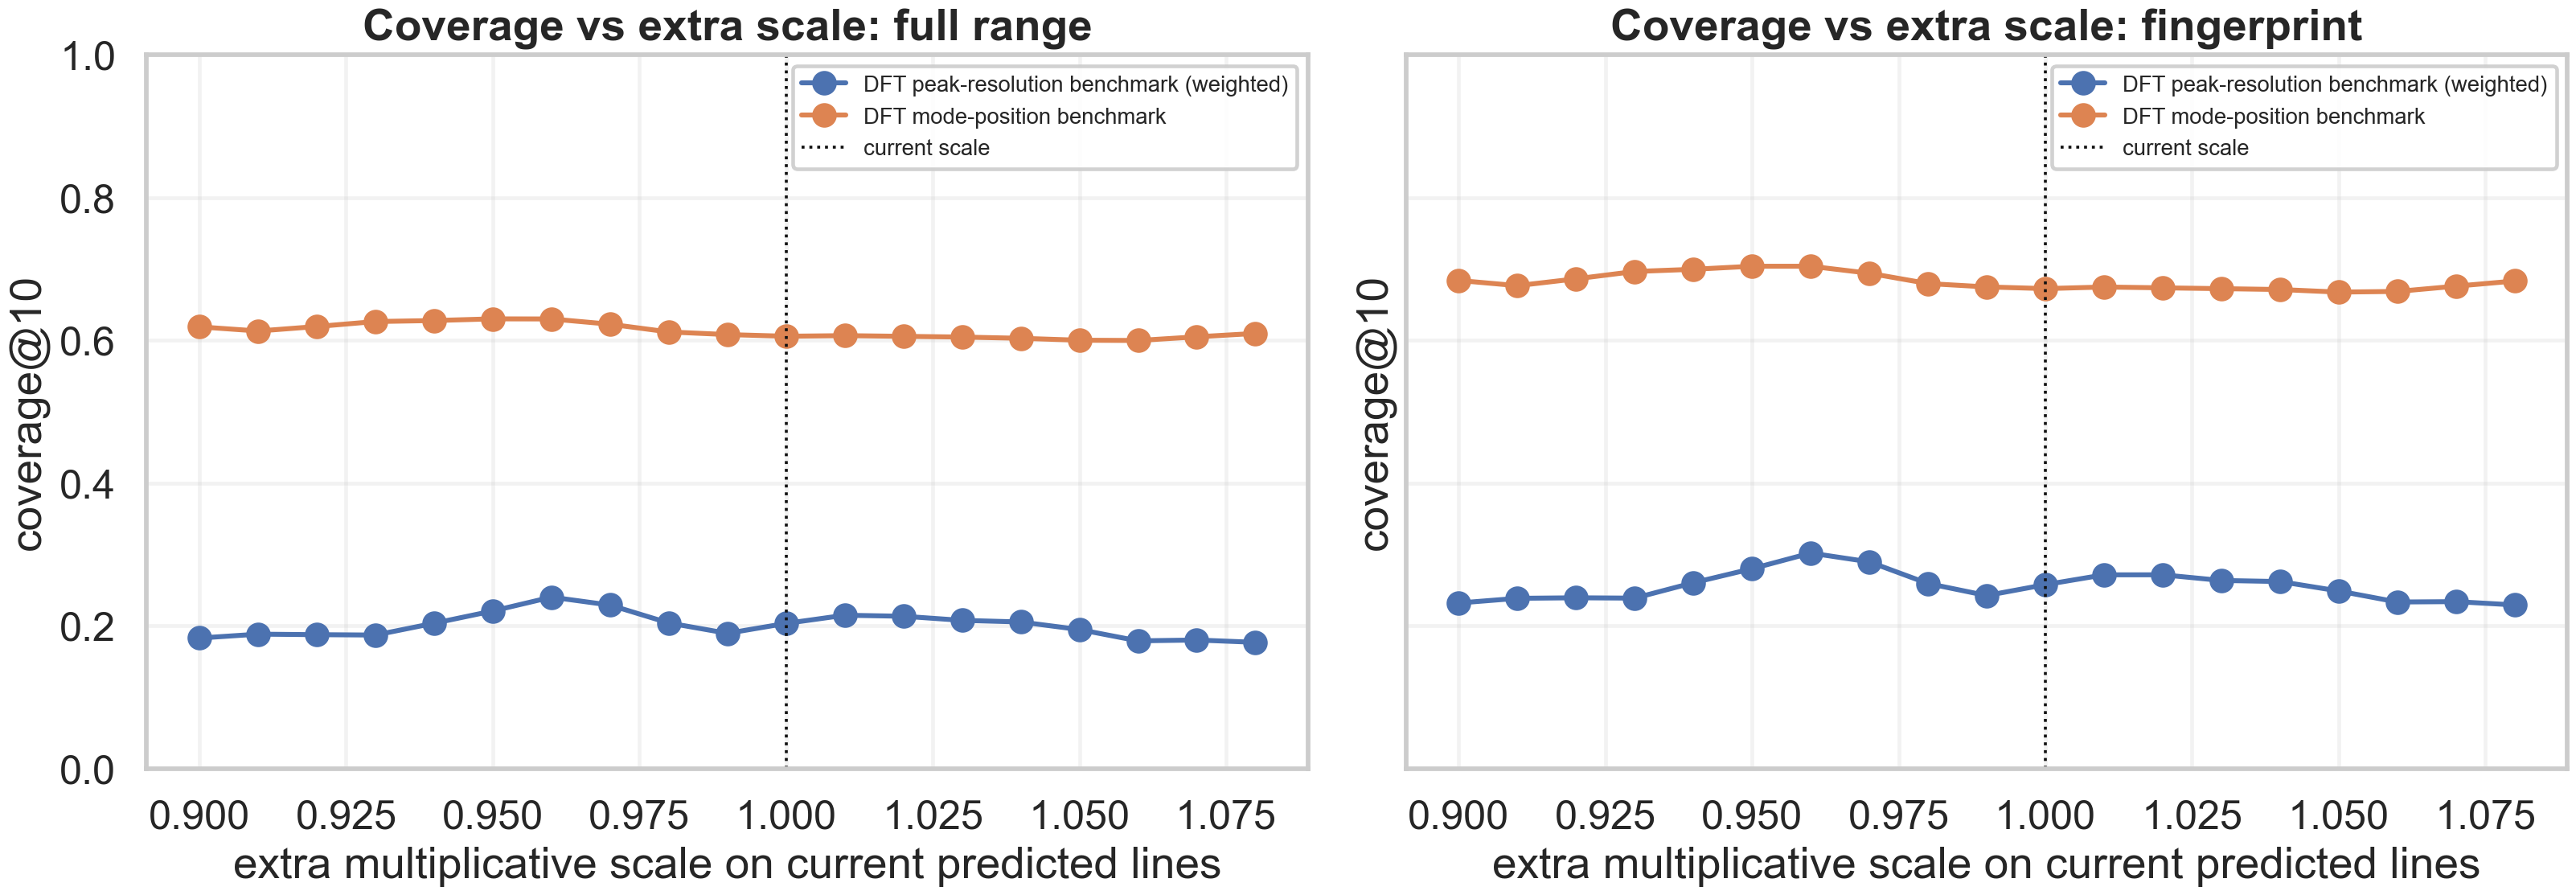


Broadened Spectra Overlays (pipeline-generated):


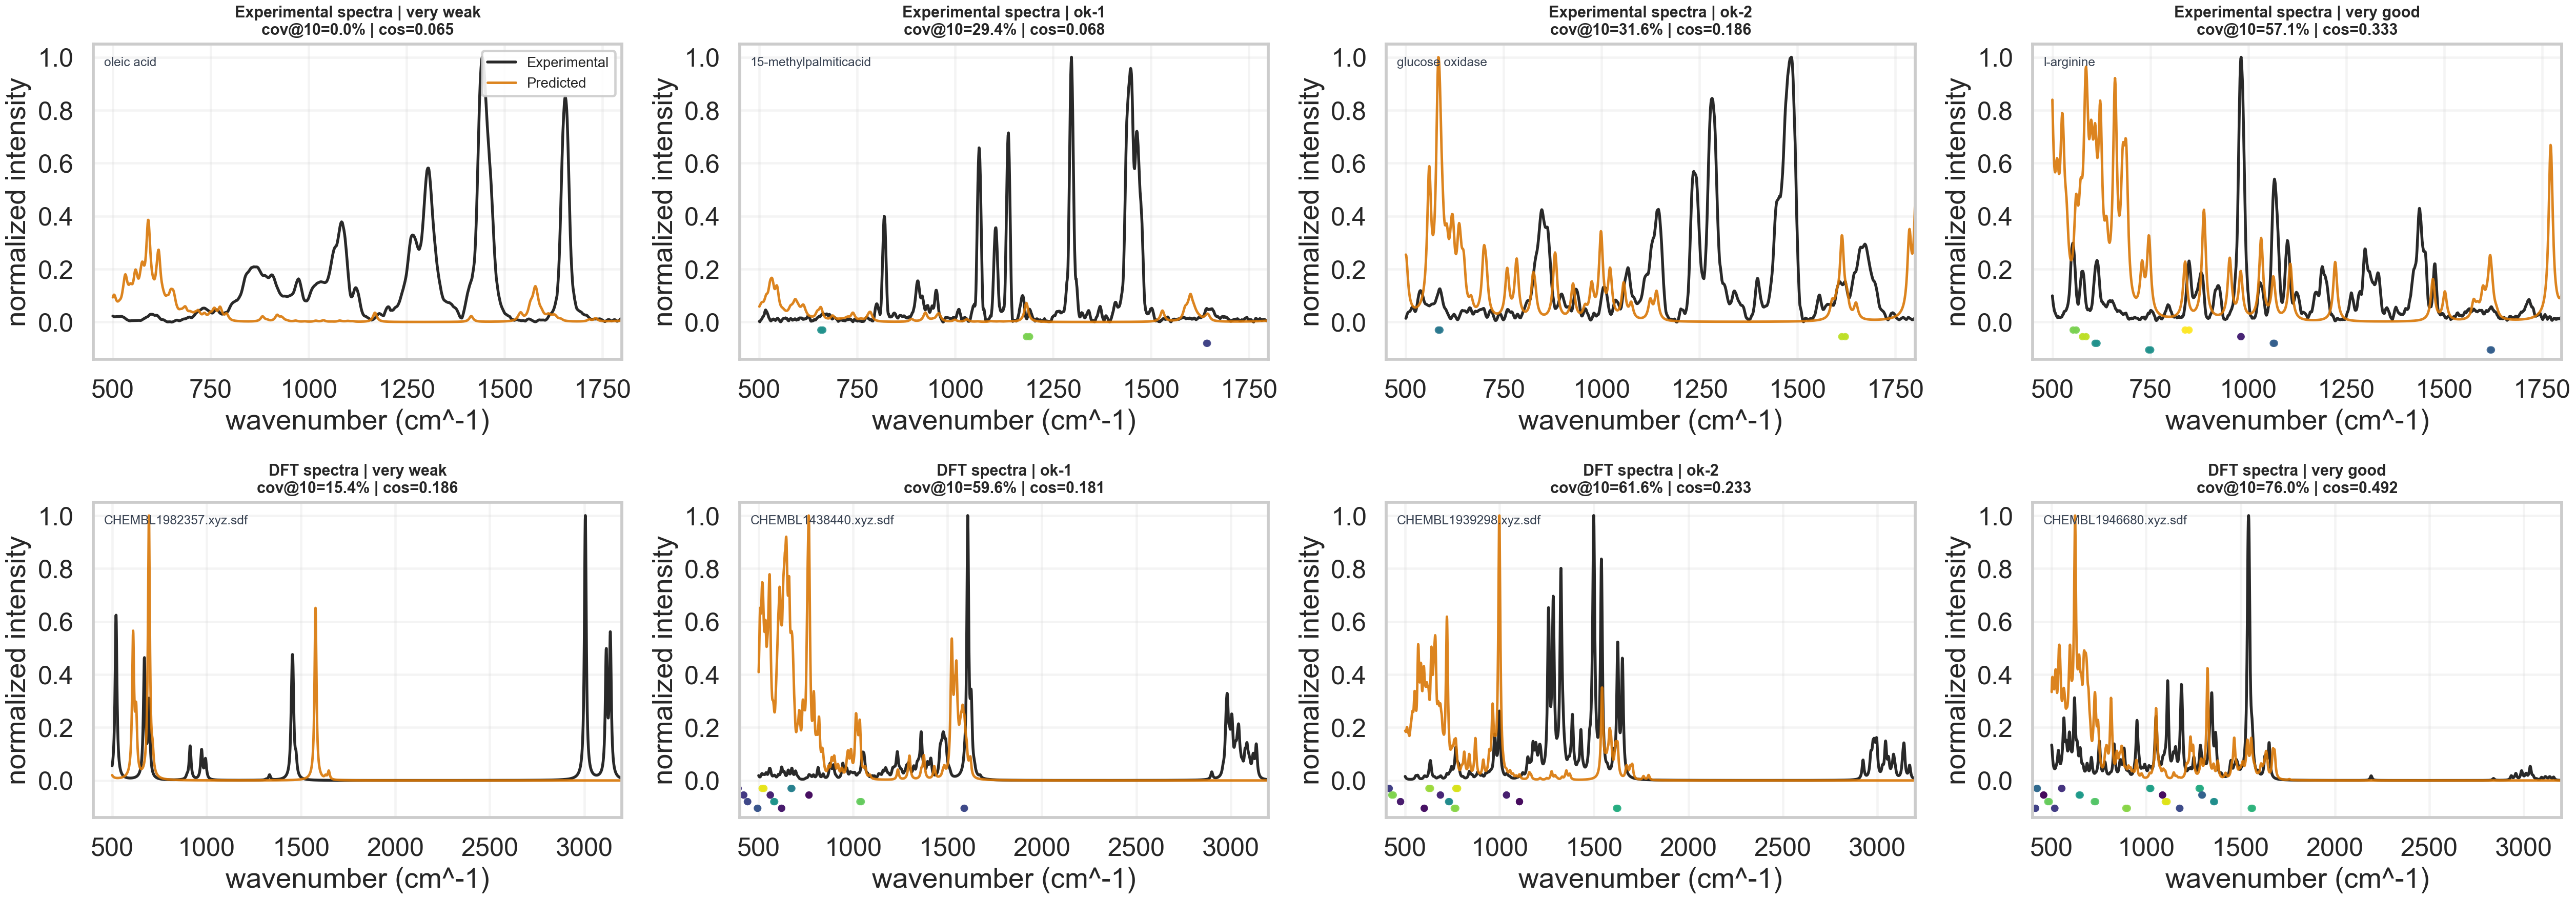


Stick Spectra Overlays (pipeline-generated):


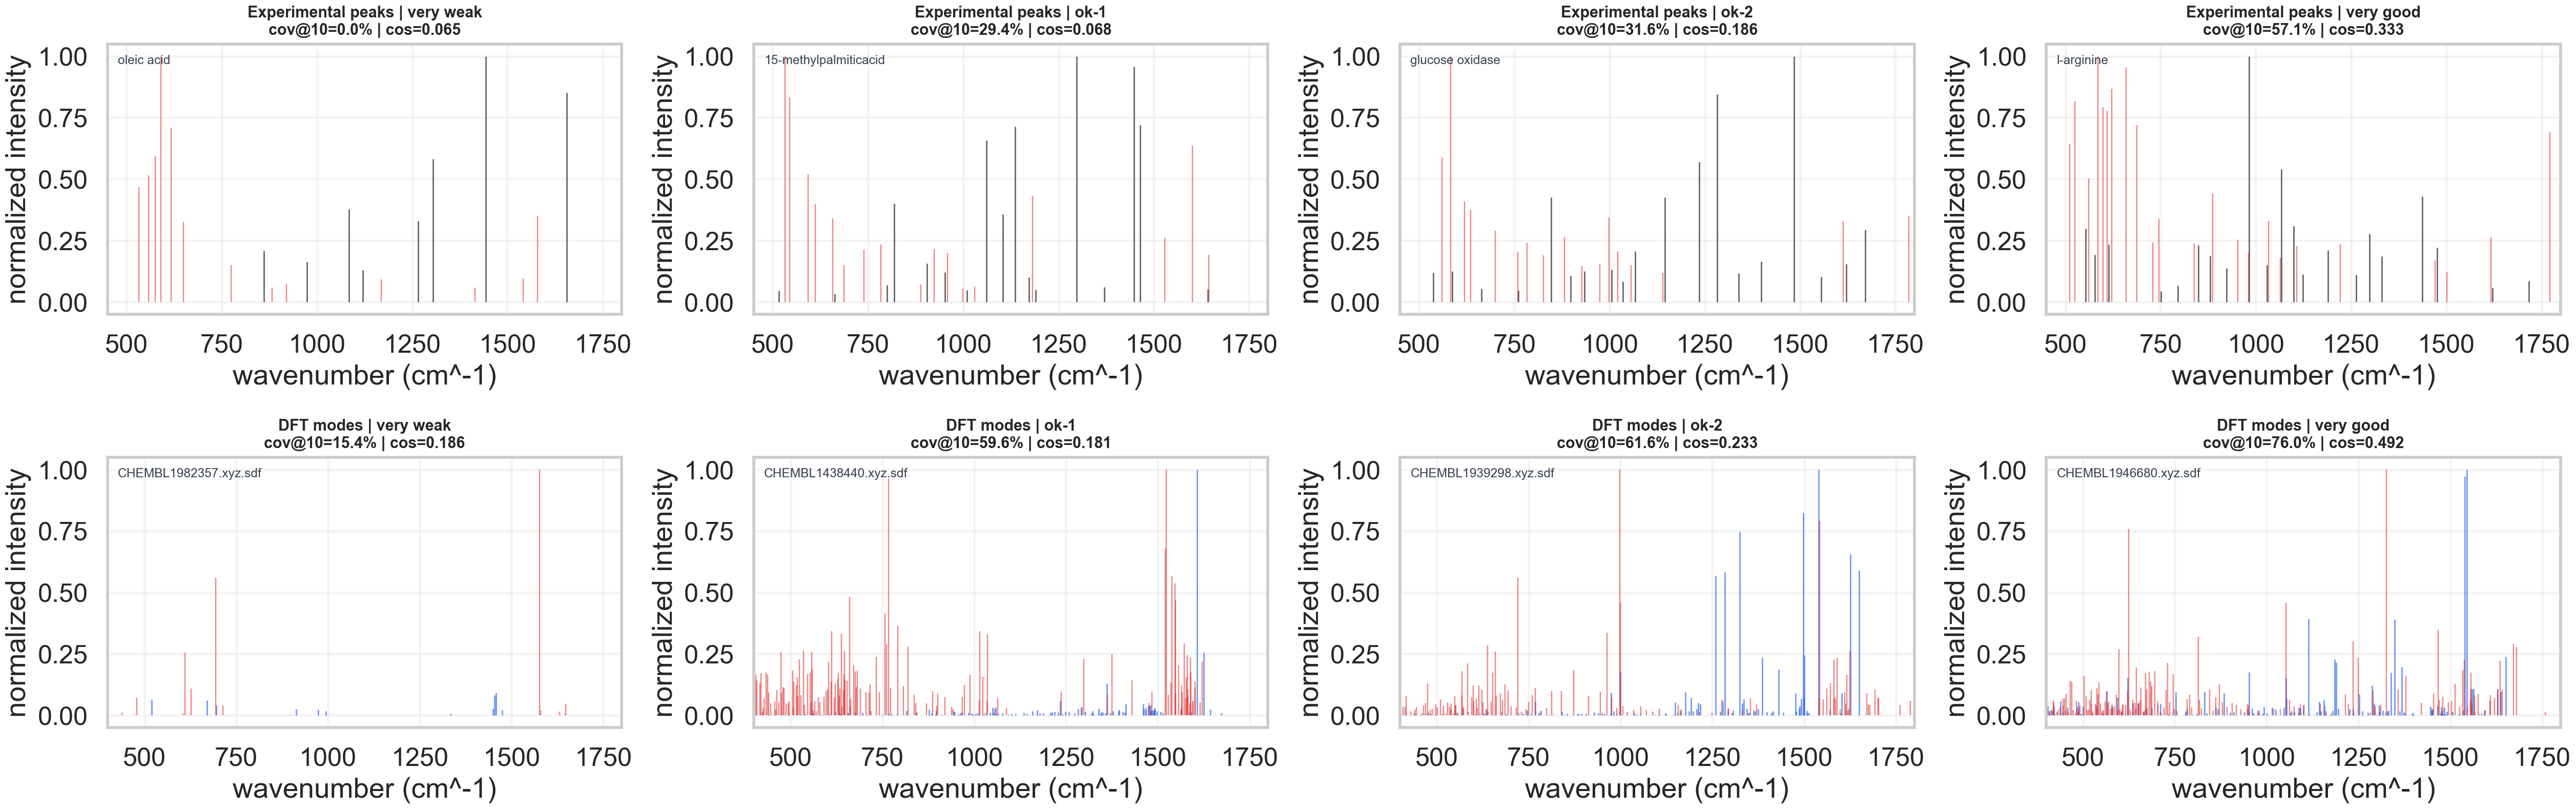

In [14]:
# === FIGURES 4-7: Re-rendered pipeline plots with better styling ===
# Use LaTeX-style superscript for cm⁻¹: r'cm$^{-1}$' in matplotlib

pm_path = OUT_DIR / 'stats_per_molecule.csv'
if not pm_path.exists():
    pm_path = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_per_molecule.csv'
pm = pd.read_csv(pm_path) if pm_path.exists() else pd.DataFrame()

# === FIGURE 4: Tolerance Sweep (pipeline) ===
tol_img = OUT_DIR / 'stats_tolerance_sweep.png'
if tol_img.exists():
    print('FIGURE 4: Coverage Tolerance Sweep')
    display(Image(filename=str(tol_img)))

# === FIGURE 5: Fingerprint Sub-Band — Bar + Boxplots ===
pw_csv = OUT_DIR / 'stats_pairwise_region_summary.csv'
if not pw_csv.exists():
    pw_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_pairwise_region_summary.csv'
pw = pd.read_csv(pw_csv) if pw_csv.exists() else pd.DataFrame()

# Also get per-molecule data for boxplots
dft_pm = pm[pm['benchmark_group'] == 'dft'].copy() if 'benchmark_group' in pm.columns else pd.DataFrame()

if len(pw) > 0:
    sub = pw[(pw['benchmark'] == 'dft_peak') & (pw['pair'] == 'DFT->Pred') & (pw['tol_cm'] == 10.0) &
             (pw['region'].isin(['fp_400_800', 'fp_800_1200', 'fp_1200_1600', 'fp_1600_1800', 'fingerprint']))].copy()
    
    region_labels = {'fp_400_800': '400\u2013800', 'fp_800_1200': '800\u20131200', 
                     'fp_1200_1600': '1200\u20131600', 'fp_1600_1800': '1600\u20131800', 'fingerprint': 'All FP'}
    order = ['400\u2013800', '800\u20131200', '1200\u20131600', '1600\u20131800', 'All FP']
    
    # Detect column names: v2 CSV uses global_weighted_coverage_any, exec_df uses weighted_coverage_any_global
    wt_cov_col = 'global_weighted_coverage_any' if 'global_weighted_coverage_any' in sub.columns else 'weighted_coverage_any_global'
    
    if len(sub) > 0 and wt_cov_col in sub.columns:
        sub['label'] = sub['region'].map(region_labels)
        
        # Try to get per-molecule boxplot data
        box_data = {}
        for region_key, label in region_labels.items():
            col = [c for c in dft_pm.columns if f'weighted_coverage_any__dft_peak__DFT->Pred__{region_key}__tol_10' in c]
            if col:
                vals = dft_pm[col[0]].dropna().values
                if len(vals) > 0:
                    box_data[label] = vals
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Panel A: Global weighted coverage bars
        present = [o for o in order if o in sub['label'].values]
        vals_list = [float(sub[sub['label']==r][wt_cov_col].iloc[0]) for r in present]
        bars = axes[0].bar(range(len(present)), vals_list,
                          color=[PALETTE[i % len(PALETTE)] for i in range(len(present))],
                          alpha=0.75, edgecolor='white', linewidth=0.8)
        axes[0].set_xticks(range(len(present)))
        axes[0].set_xticklabels([f'{r}\ncm$^{{-1}}$' for r in present], fontsize=10)
        axes[0].set_ylabel(r'Intensity-Weighted Coverage @ $\pm$10 cm$^{-1}$')
        axes[0].set_title('(a) Sub-Band Weighted Coverage')
        axes[0].set_ylim(0, 0.65)
        for bar, val in zip(bars, vals_list):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Panel B: Per-molecule boxplots (if data available)
        if box_data:
            bp_order = [o for o in order if o in box_data]
            bp = axes[1].boxplot([box_data[r] for r in bp_order], labels=bp_order,
                                patch_artist=True, widths=0.6, showfliers=True,
                                medianprops=dict(color=C_REF, lw=2),
                                whiskerprops=dict(color='0.5', lw=1),
                                capprops=dict(color='0.5', lw=1),
                                flierprops=dict(marker='.', markersize=2, alpha=0.2, color='0.4'))
            for i, (patch, r) in enumerate(zip(bp['boxes'], bp_order)):
                patch.set_facecolor(PALETTE[i % len(PALETTE)])
                patch.set_alpha(0.55)
                patch.set_edgecolor('0.3')
            axes[1].set_ylabel(r'Per-Molecule Weighted Coverage @ $\pm$10 cm$^{-1}$')
            axes[1].set_title('(b) Per-Molecule Distribution')
            axes[1].tick_params(axis='x', rotation=0)
            # Add x-axis unit labels
            axes[1].set_xticklabels([f'{r}\ncm$^{{-1}}$' for r in bp_order], fontsize=9)
        else:
            axes[1].text(0.5, 0.5, 'Per-molecule data not available', ha='center', va='center',
                        transform=axes[1].transAxes, fontsize=11, color='0.5')
        
        fig.savefig(OUT_DIR / 'fig5_subband_coverage.png', dpi=300)
        fig.savefig(OUT_DIR / 'fig5_subband_coverage.pdf')
        plt.show()
        print('Saved fig5_subband_coverage')
    else:
        print(f'Weighted coverage column not found. Available columns: {list(sub.columns[:10])}')

# === FIGURE 6: Intensity Agreement — Custom Bland-Altman ===
ll_csv = OUT_DIR / 'stats_line_level_matches.csv'
if not ll_csv.exists():
    ll_csv = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'stats' / 'stats_line_level_matches.csv'

if ll_csv.exists():
    ll = pd.read_csv(ll_csv)
    # v2 CSV uses source_intensity / target_intensity (not source_int_norm / target_int_norm)
    src_int = next((c for c in ['source_int_norm', 'source_intensity'] if c in ll.columns), None)
    tgt_int = next((c for c in ['target_int_norm', 'target_intensity'] if c in ll.columns), None)
    
    if src_int and tgt_int:
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        
        for col_idx, (bm, pair, region, title_str, color) in enumerate([
            ('dft_peak', 'DFT->Pred', 'fingerprint', 'DFT Peak-Resolution (FP)', C_PRED),
            ('experimental_peak', 'Exp->Pred', 'fingerprint', 'Experimental (FP)', C_EXP),
        ]):
            subset = ll[(ll['benchmark'] == bm) & (ll['pair'] == pair) &
                         (ll['region'] == region) & (ll['tol_cm'] == 10.0)]
            if len(subset) == 0:
                continue
            
            si = subset[src_int].dropna().values
            ti = subset[tgt_int].dropna().values
            n = min(len(si), len(ti))
            si, ti = si[:n], ti[:n]
            
            # Normalize to [0, 1] for Bland-Altman plotting
            si_max = si.max() if si.max() > 0 else 1.0
            ti_max = ti.max() if ti.max() > 0 else 1.0
            si_norm = si / si_max
            ti_norm = ti / ti_max
            
            # Top row: Scatter
            ax = axes[0, col_idx]
            ax.scatter(si_norm, ti_norm, s=4, alpha=0.15, color=color, rasterized=True)
            ax.plot([0, 1], [0, 1], 'k-', lw=1, alpha=0.4)
            ax.set_xlabel('Reference Intensity (normalized)')
            ax.set_ylabel('Predicted Intensity (normalized)')
            ax.set_title(f'{title_str}\n(n = {n:,} matched pairs)')
            ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
            ax.set_aspect('equal')
            
            # Bottom row: Bland-Altman
            ax = axes[1, col_idx]
            means = (si_norm + ti_norm) / 2
            diffs = ti_norm - si_norm
            mean_diff = np.mean(diffs)
            sd_diff = np.std(diffs)
            
            ax.scatter(means, diffs, s=3, alpha=0.1, color=color, rasterized=True)
            ax.axhline(mean_diff, color=C_REF, lw=1.5, ls='-', label=f'Mean diff: {mean_diff:.3f}')
            ax.axhline(mean_diff + 1.96*sd_diff, color=WONG['orange'], lw=1, ls='--',
                       label=f'+1.96 SD: {mean_diff+1.96*sd_diff:.2f}')
            ax.axhline(mean_diff - 1.96*sd_diff, color=WONG['orange'], lw=1, ls='--',
                       label=f'\u22121.96 SD: {mean_diff-1.96*sd_diff:.2f}')
            ax.set_xlabel('Mean of (Reference, Predicted)')
            ax.set_ylabel('Difference (Predicted \u2212 Reference)')
            ax.set_title(f'Bland\u2013Altman: {title_str}')
            ax.legend(fontsize=8, loc='upper right')
            ax.set_xlim(-0.02, 0.8)
        
        fig.savefig(OUT_DIR / 'fig6_intensity_agreement.png', dpi=300)
        fig.savefig(OUT_DIR / 'fig6_intensity_agreement.pdf')
        plt.show()
        print('Saved fig6_intensity_agreement')
    else:
        # Fallback: show pipeline version
        print(f'Intensity columns not found. Available: {[c for c in ll.columns if "int" in c.lower()]}')
        int_img = OUT_DIR / 'stats_intensity_agreement.png'
        if int_img.exists():
            print('FIGURE 6: Intensity Agreement (pipeline version)')
            display(Image(filename=str(int_img)))

# === FIGURE 7: Scale Sweep ===
scale_img = OUT_DIR / 'stats_scale_sweep.png'
if scale_img.exists():
    print('\nFIGURE 7: Scale Factor Sensitivity')
    display(Image(filename=str(scale_img)))

# === Spectral Overlays (pipeline-generated) ===
for pname, title in [('stats_broadened_overlays', 'Broadened Spectra Overlays'),
                      ('stats_stick_overlays', 'Stick Spectra Overlays')]:
    p = OUT_DIR / f'{pname}.png'
    if p.exists():
        print(f'\n{title} (pipeline-generated):')
        display(Image(filename=str(p)))

In [15]:
# === FINAL SUMMARY — all figures saved to OUT_DIR ===
print(f'All outputs saved to: {OUT_DIR}')
print(f'\nFiles generated:')
for f in sorted(OUT_DIR.iterdir()):
    size = f.stat().st_size
    print(f'  {f.name:45s} {size:>10,} bytes')

# Verify key numbers — merge primary_metrics and assessment so all keys are available
pm = {**summary.get('primary_metrics', {}), **summary.get('assessment', {})}
def _fmt(val, fmt='.1%'):
    try: return f'{float(val):{fmt}}'
    except: return str(val)

print(f'\n=== KEY NUMBERS FOR PAPER ===')
print(f'DFT raw-line full coverage@10:        {_fmt(pm.get("dft_raw_full_coverage10", "N/A"))}')
print(f'DFT raw-line full weighted cov@10:    {_fmt(pm.get("dft_raw_full_weighted_coverage10", "N/A"))}')
print(f'DFT raw-line full median |Δν|:        {_fmt(pm.get("dft_raw_full_median_abs_dnu_cm", "N/A"), ".2f")} cm⁻¹')
print(f'Experimental FP weighted cov@10:      {_fmt(pm.get("experimental_fingerprint_weighted_coverage10", "N/A"))}')
print(f'DFT full cosine median:               {_fmt(pm.get("dft_full_cosine_median", "N/A"), ".3f")}')

print(f'\nFingerprint numbers (from exec_df):')
fp = exec_df[(exec_df['benchmark'].str.startswith('DFT mode-position')) & 
             (exec_df['region']=='fingerprint') & (exec_df['tol_cm']==10.0)]
if len(fp) > 0:
    r = fp.iloc[0]
    print(f'  DFT FP coverage@10:    {r["coverage_any_global"]:.1%}')
    print(f'  DFT FP wt. cov@10:    {r["weighted_coverage_any_global"]:.1%}')
    print(f'  DFT FP F1@10:          {r["f1"]:.3f}')
else:
    print('  Fingerprint row not found in exec_df')

All outputs saved to: /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/stats_v2

Files generated:
  bias_assessment.csv                                  388 bytes
  coverage_10_15.csv                                   381 bytes
  fig1_frequency_parity.pdf                         38,462 bytes
  fig1_frequency_parity.png                        281,512 bytes
  fig2_error_distributions.pdf                      44,294 bytes
  fig2_error_distributions.png                     320,821 bytes
  fig3_molecule_sizes.pdf                           38,599 bytes
  fig3_molecule_sizes.png                          254,580 bytes
  fig4_narrative_plots.pdf                          52,439 bytes
  fig4_narrative_plots.png                         789,037 bytes
  fig5_subband_coverage.pdf                         35,420 bytes
  fig5_subband_coverage.png                        253,842 bytes
  fig6_intensity_agreement.pdf                     319,625 bytes
  fig6_intensity_agreement.png         